In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
%pip install xgboost streamlit requests beautifulsoup4 joblib plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
matches    = pd.read_csv('../data/all_ipl_matches_data.csv')
deliveries = pd.read_csv('../data/all_ball_by_ball_data.csv')
players    = pd.read_csv('../data/all_players-data-updated.csv')
teams      = pd.read_csv('../data/all_teams_data.csv')
print('matches shape:',    matches.shape)
print('deliveries shape:', deliveries.shape)
print('players shape:',    players.shape)
print('teams shape:',      teams.shape)

matches shape: (1169, 23)
deliveries shape: (278205, 30)
players shape: (772, 6)
teams shape: (16, 2)


In [4]:
print('matches columns:',    matches.columns.tolist())
print('deliveries columns:', deliveries.columns.tolist())
print('players columns:',    players.columns.tolist())
print('teams columns:',      teams.columns.tolist())

matches columns: ['match_id', 'season_id', 'balls_per_over', 'city', 'match_date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'result']
deliveries columns: ['season_id', 'match_id', 'batter', 'bowler', 'non_striker', 'team_batting', 'team_bowling', 'over_number', 'ball_number', 'batter_runs', 'extras', 'total_runs', 'batsman_type', 'bowler_type', 'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball', 'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs', 'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs', 'wicket_kind', 'is_super_over', 'innings']
players columns: ['player_id', 'player_name', 'bat_style', 'bowl_style', 'field_pos', 'player_full_name']
teams columns: ['team_id', 'team_name']


In [5]:
matches.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,M Chinnaswamy Stadium,1,1,6,field,6,140.0,NaN,46.0,win
1,1082591,2017,6,Hyderabad,2017-04-05,Indian Premier League,1.0,male,T20,T20,...,"Rajiv Gandhi International Stadium, Uppal",1,2,1,field,2,35.0,NaN,15.0,win
2,1082592,2017,6,Pune,2017-04-06,Indian Premier League,2.0,male,T20,T20,...,Maharashtra Cricket Association Stadium,4,4,3,field,4,NaN,7.0,36.0,win
3,1082593,2017,6,Rajkot,2017-04-07,Indian Premier League,3.0,male,T20,T20,...,Saurashtra Cricket Association Stadium,6,5,6,field,6,NaN,10.0,57.0,win
4,1082594,2017,6,Indore,2017-04-08,Indian Premier League,4.0,male,T20,T20,...,Holkar Cricket Stadium,494,494,4,field,494,NaN,6.0,71.0,win


In [6]:
deliveries.head()

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,...,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,6,1,0,0,0,...,False,False,0,0,1,0,0,NaN,False,1
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,1,0,...,False,False,0,0,0,0,0,NaN,False,1
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,2,0,...,False,False,1,0,0,0,0,NaN,False,1
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,3,0,...,False,False,0,0,0,0,0,NaN,False,1
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,4,0,...,False,False,0,0,0,0,0,NaN,False,1


In [7]:
players.head()

,player_id,player_name,bat_style,bowl_style,field_pos,player_full_name
0,6730,Mohsin Khan,Left hand Bat,Left arm Medium fast,NaN,Mohsin Khan
1,22,Rashid Khan,Right hand Bat,Legbreak Googly,,Rashid Khan Arman
2,590,K Rabada,Left hand Bat,Right arm Fast,,Kagiso Rabada
3,1424,SN Khan,Right hand Bat,Legbreak,,Sarfaraz Naushad Khan
4,963,MN Samuels,Right hand Bat,Right arm Offbreak,,Marlon Nathaniel Samuels


In [8]:
teams.head()

,team_id,team_name
0,1,Royal Challengers Bangalore
1,2,Sunrisers Hyderabad
2,3,Mumbai Indians
3,4,Rising Pune Supergiant
4,5,Gujarat Lions


**Build Team ID to Name Mapping**

In [9]:
team_map = dict(zip(teams['team_id'], teams['team_name']))
team_map

{1: 'Royal Challengers Bangalore',
 2: 'Sunrisers Hyderabad',
 3: 'Mumbai Indians',
 4: 'Rising Pune Supergiant',
 5: 'Gujarat Lions',
 6: 'Kolkata Knight Riders',
 129: 'Chennai Super Kings',
 134: 'Rajasthan Royals',
 252: 'Delhi Capitals',
 494: 'Punjab Kings',
 614: 'Lucknow Super Giants',
 615: 'Gujarat Titans',
 1068: 'Deccan Chargers',
 1414: 'Kochi Tuskers Kerala',
 1419: 'Pune Warriors',
 3604: 'Rising Pune Supergiants'}

**Applying Mapping to Matches + Clean**

In [10]:
matches['team1']        = matches['team1'].map(team_map)
matches['team2']        = matches['team2'].map(team_map)
matches['toss_winner']  = matches['toss_winner'].map(team_map)
matches['winner']       = matches['match_winner'].map(team_map)
matches.rename(columns={'match_id': 'id'}, inplace=True)
matches = matches[matches['result'] == 'win'].reset_index(drop=True)

matches['match_date'] = pd.to_datetime(matches['match_date'], errors='coerce')
matches = matches.sort_values('match_date').reset_index(drop=True)

print("Matches after cleaning:", matches.shape)
print(matches[['id','team1','team2','toss_winner','toss_decision','winner','venue','season']].head(5))

Matches after cleaning: (1146, 24)
       id                        team1                        team2  \
0  335982  Royal Challengers Bangalore        Kolkata Knight Riders   
1  335984               Delhi Capitals             Rajasthan Royals   
2  335983                 Punjab Kings          Chennai Super Kings   
3  335985               Mumbai Indians  Royal Challengers Bangalore   
4  335986        Kolkata Knight Riders          Sunrisers Hyderabad   

                   toss_winner toss_decision                       winner  \
0  Royal Challengers Bangalore         field        Kolkata Knight Riders   
1             Rajasthan Royals           bat               Delhi Capitals   
2          Chennai Super Kings           bat          Chennai Super Kings   
3               Mumbai Indians           bat  Royal Challengers Bangalore   
4          Sunrisers Hyderabad           bat        Kolkata Knight Riders   

                                        venue season  
0                   

**Applying Mapping to Deliveries + Rename Columns**

In [11]:
deliveries['batting_team'] = deliveries['team_batting'].map(team_map)
deliveries['bowling_team'] = deliveries['team_bowling'].map(team_map)
deliveries.rename(columns={
    'batter':       'batsman',
    'batter_runs':  'batsman_runs',
    'wicket_kind':  'dismissal_kind',
    'innings':      'inning'
}, inplace=True)
print("Deliveries after cleaning:", deliveries.shape)
print(deliveries[['match_id','batsman','bowler','batsman_runs','total_runs',
                  'batting_team','bowling_team','dismissal_kind','inning']].head(5))

Deliveries after cleaning: (278205, 32)
   match_id      batsman   bowler  batsman_runs  total_runs  \
0    335982   SC Ganguly  P Kumar             0           1   
1    335982  BB McCullum  P Kumar             0           0   
2    335982  BB McCullum  P Kumar             0           1   
3    335982  BB McCullum  P Kumar             0           0   
4    335982  BB McCullum  P Kumar             0           0   

            batting_team                 bowling_team dismissal_kind  inning  
0  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  
1  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  
2  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  
3  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  
4  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  


**Explore Matches**

In [12]:
print("Seasons covered:", sorted(matches['season'].unique()))
print("Total matches:", len(matches))
print("Total unique teams:", len(matches['team1'].unique()))
print("Total venues:", len(matches['venue'].unique()))
print()
print('Toss decisions:')
print(matches['toss_decision'].value_counts())
print()
print('Null values in key columns:')
print(matches[['team1','team2','winner','venue','toss_winner','toss_decision']].isnull().sum())

Seasons covered: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025']
Total matches: 1146
Total unique teams: 14
Total venues: 59

Toss decisions:
toss_decision
field    750
bat      396
Name: count, dtype: int64

Null values in key columns:
team1            0
team2            0
winner           0
venue            0
toss_winner      0
toss_decision    0
dtype: int64


**Explore Deliveries**

In [13]:
print('Total balls bowled:',  len(deliveries))
print('Unique batsmen:',        deliveries['batsman'].nunique())
print('Unique bowlers:',        deliveries['bowler'].nunique())
print("Innings values:",        deliveries['inning'].unique())
print("Dismissal kinds:",       deliveries['dismissal_kind'].dropna().unique())
print()
print("Null values in key columns:")
print(deliveries[['batsman','bowler','batsman_runs','total_runs']].isnull().sum())

Total balls bowled: 278205
Unique batsmen: 703
Unique bowlers: 550
Innings values: [1 2 3 4 5 6]
Dismissal kinds: ['caught' 'bowled' 'run out' 'lbw' 'caught and bowled' 'stumped'
 'retired hurt' 'hit wicket' 'obstructing the field' 'retired out']

Null values in key columns:
batsman         0
bowler          0
batsman_runs    0
total_runs      0
dtype: int64


**Computing Batting Stats**

In [14]:
dismissal_types = ['bowled','caught','lbw','stumped','caught and bowled','hit wicket','run out']
dismissals_df = (
    deliveries[deliveries['dismissal_kind'].isin(dismissal_types)]
    .groupby('batsman').size()
    .reset_index(name='dismissals'))

In [15]:
batting = deliveries.groupby('batsman').agg(
    total_runs=   ('batsman_runs', 'sum'),
    balls_faced=  ('ball_number',  'count'),
    innings_played=('match_id',    'nunique')
).reset_index()

batting = batting.merge(dismissals_df, on='batsman', how='left')
batting['dismissals'] = batting['dismissals'].fillna(0)

batting['strike_rate'] = (batting['total_runs'] / batting['balls_faced']) * 100
batting['batting_avg'] = np.where(
    batting['dismissals'] > 0,
    batting['total_runs'] / batting['dismissals'],
    batting['total_runs'])

batting = batting[batting['innings_played'] > 5].reset_index(drop=True)
batting.columns = ['player','total_runs','balls_faced','innings','dismissals','strike_rate','batting_avg']
print("Batting shape:", batting.shape)
batting.head()

Batting shape: (423, 7)


,player,total_runs,balls_faced,innings,dismissals,strike_rate,batting_avg
0,A Ashish Reddy,280,196,23,15.0,142.857143,18.666667
1,A Badoni,963,740,46,36.0,130.135135,26.750000
2,A Chopra,53,75,6,5.0,70.666667,10.600000
3,A Kamboj,16,15,6,2.0,106.666667,8.000000
4,A Kumble,35,49,15,2.0,71.428571,17.500000


In [16]:
player_match_sr = (
    deliveries.groupby(['batsman','match_id'])
    .agg(runs=('batsman_runs','sum'), balls=('ball_number','count'))
    .reset_index())
player_match_sr['match_sr'] = (player_match_sr['runs'] / player_match_sr['balls']) * 100
player_match_sr = player_match_sr.sort_values('match_id')

player_match_sr['rolling_sr'] = (
    player_match_sr.groupby('batsman')['match_sr']
    .transform(lambda x: x.rolling(5, min_periods=1).mean()))

recent_sr = (
    player_match_sr.groupby('batsman')['rolling_sr']
    .last().reset_index()
    .rename(columns={'batsman':'player','rolling_sr':'recent_strike_rate'}))

batting = batting.merge(recent_sr, on='player', how='left')
batting['recent_strike_rate'] = batting['recent_strike_rate'].fillna(batting['strike_rate'])
print(batting.nlargest(10,'batting_avg')[['player','batting_avg','strike_rate','total_runs','balls_faced','innings']])

              player  batting_avg  strike_rate  total_runs  balls_faced  \
142    Iqbal Abdulla    88.000000   102.325581          88           86   
64   B Sai Sudharsan    52.735294   140.187647        1793         1279   
271   PD Collingwood    50.750000   127.672956         203          159   
179         KL Rahul    45.521739   132.632379        5235         3947   
132          HM Amla    44.384615   138.038278         577          418   
108        DP Conway    43.200000   136.020151        1080          794   
379   Shashank Singh    42.944444   151.568627         773          510   
385         T Stubbs    41.823529   160.859729         711          442   
18    AB de Villiers    41.448000   148.580442        5181         3487   
161        JP Duminy    41.408163   120.773810        2029         1680   

     innings  
142       13  
64        40  
271        7  
179      135  
132       16  
108       28  
379       33  
385       30  
18       170  
161       75  


**Computing Bowling Stats**

In [17]:
bowler_wicket_type = ['bowled','caught','lbw','stumped','caught and bowled','hit wicket']
wicket_df = deliveries[deliveries['dismissal_kind'].isin(bowler_wicket_type)]

bowling = deliveries.groupby('bowler').agg(
    ball_bowled=  ('ball_number', 'count'),
    runs_conceded=('total_runs',  'sum'),
    matches=      ('match_id',    'nunique')
).reset_index()

wicketes = wicket_df.groupby('bowler').size().reset_index(name='wickets')
bowling  = bowling.merge(wicketes, on='bowler', how='left')
bowling['wickets']     = bowling['wickets'].fillna(0)
bowling['economy']     = bowling['runs_conceded'] / (bowling['ball_bowled'] / 6)
bowling['bowling_avg'] = bowling['runs_conceded'] / bowling['wickets'].replace(0, np.nan)

bowler_over_economy = (
    deliveries.groupby(['bowler','match_id','over_number'])['total_runs']
    .sum().reset_index())
bowler_over_economy.columns = ['bowler','match_id','over_number','runs_in_over']
bowler_over_economy['over_economy'] = bowler_over_economy['runs_in_over']

bowler_recent_eco = (
    bowler_over_economy.groupby('bowler')['over_economy']
    .apply(lambda x: x.rolling(window=30, min_periods=1).mean().iloc[-1],
           include_groups=False)
    .reset_index())
bowler_recent_eco.columns = ['bowler','recent_economy']

bowling = bowling.merge(bowler_recent_eco, on='bowler', how='left')
bowling['recent_economy'] = bowling['recent_economy'].fillna(bowling['economy'])
bowling.columns = ['player','ball_bowled','runs_conceded','matches','wickets',
                   'economy','bowling_avg','recent_economy']
print("Bowling shape:", bowling.shape)
print("Bowling columns:", bowling.columns.tolist())

Bowling shape: (550, 8)
Bowling columns: ['player', 'ball_bowled', 'runs_conceded', 'matches', 'wickets', 'economy', 'bowling_avg', 'recent_economy']


In [18]:
top_bowl = bowling[bowling['matches'] >= 20].nsmallest(10, 'economy')
print(top_bowl[['player','economy','bowling_avg','wickets','matches']])

               player   economy  bowling_avg  wickets  matches
7            A Kumble  6.646999    24.200000     45.0       42
271    M Muralitharan  6.698292    27.578125     64.0       66
188           J Yadav  6.738693    55.875000      8.0       20
391  RE van der Merwe  6.791209    24.523810     21.0       21
141          DW Steyn  6.791411    26.628866     97.0       95
460         SP Narine  6.825153    26.192708    192.0      187
132        DL Vettori  6.833121    31.928571     28.0       34
182           J Botha  6.922426    32.720000     25.0       34
452        SL Malinga  7.032952    20.505882    170.0      122
167   Harbhajan Singh  7.038330    27.340000    150.0      160


**Merging into Player Lookup + Save**

In [19]:
player_lookup = pd.merge(batting, bowling, on='player', how='outer')
player_lookup['wickets']    = player_lookup['wickets'].fillna(0)
player_lookup['innings']    = player_lookup['innings'].fillna(0)
player_lookup['total_runs'] = player_lookup['total_runs'].fillna(0)

for col in ['batting_avg','strike_rate','recent_strike_rate','economy','recent_economy','bowling_avg']:
    median_val = player_lookup[col].median()
    player_lookup[col] = player_lookup[col].fillna(median_val)

print("Player lookup shape:", player_lookup.shape)
print(player_lookup.columns.tolist())
player_lookup.to_csv('../player_stats/player_lookup.csv', index=False)

Player lookup shape: (683, 15)
['player', 'total_runs', 'balls_faced', 'innings', 'dismissals', 'strike_rate', 'batting_avg', 'recent_strike_rate', 'ball_bowled', 'runs_conceded', 'matches', 'wickets', 'economy', 'bowling_avg', 'recent_economy']


**Match Feature Engineering**

In [20]:
player_lookup = pd.read_csv('../player_stats/player_lookup.csv')
print(player_lookup.shape)
player_lookup.head()

(683, 15)


,player,total_runs,balls_faced,innings,dismissals,strike_rate,batting_avg,recent_strike_rate,ball_bowled,runs_conceded,matches,wickets,economy,bowling_avg,recent_economy
0,A Ashish Reddy,280.0,196.0,23.0,15.0,142.857143,18.666667,120.444444,270.0,400.0,20.0,18.0,8.888889,22.222222,9.000000
1,A Badoni,963.0,740.0,46.0,36.0,130.135135,26.750000,138.019812,35.0,50.0,7.0,4.0,8.571429,12.500000,7.142857
2,A Chandila,0.0,NaN,0.0,NaN,118.803419,19.727273,93.821429,234.0,245.0,12.0,11.0,6.282051,22.272727,6.400000
3,A Chopra,53.0,75.0,6.0,5.0,70.666667,10.600000,62.977778,NaN,NaN,NaN,0.0,8.529554,31.396129,9.100000
4,A Choudhary,0.0,NaN,0.0,NaN,118.803419,19.727273,93.821429,108.0,144.0,5.0,5.0,8.000000,28.800000,8.470588


**Compute Opening Batsmen Stats Per Team**

In [21]:

batting_order = (
    deliveries[deliveries['inning'] == 1]
    .groupby(['match_id','batting_team'])['batsman']
    .apply(list, include_groups=False)
    .reset_index())
batting_order.columns = ['match_id','team','batting_order']
batting_order['opener1'] = batting_order['batting_order'].apply(
    lambda x: x[0] if len(x) > 0 else None)
batting_order['opener2'] = batting_order['batting_order'].apply(
    lambda x: next((p for p in x if p != x[0]), None) if len(x) > 1 else None)

In [22]:
def get_opener_stats(team, player_lookup, batting_order):
    team_openers = batting_order[batting_order['team'] == team]
    all_openers  = pd.concat([team_openers['opener1'].dropna(), team_openers['opener2'].dropna()])
    if all_openers.empty:
        return {'opener_avg_batting_avg': 25, 'opener_avg_strike_rate': 130}
    top_openers  = all_openers.value_counts().head(3).index.tolist()
    opener_stats = player_lookup[player_lookup['player'].isin(top_openers)]
    return {
        'opener_avg_batting_avg': opener_stats['batting_avg'].mean(),
        'opener_avg_strike_rate': opener_stats['strike_rate'].mean()
    }

team_list = matches['team1'].dropna().unique().tolist()
team_oppener_lookup = {}
for team in team_list:
    team_oppener_lookup[team] = get_opener_stats(team, player_lookup, batting_order)

print(len(team_oppener_lookup), "teams")
print("Sample:", list(team_oppener_lookup.items())[:2])

14 teams
Sample: [('Royal Challengers Bangalore', {'opener_avg_batting_avg': np.float64(37.310471530784035), 'opener_avg_strike_rate': np.float64(134.63348807233297)}), ('Delhi Capitals', {'opener_avg_batting_avg': np.float64(30.8169487307118), 'opener_avg_strike_rate': np.float64(142.49395823462672)})]


**Team Stats from XI**

In [23]:
def get_team_stats(player_list, player_lookup):
    stats = player_lookup[player_lookup['player'].isin(player_list)]
    if stats.empty:
        return {'avg_batting_avg':25,'avg_strike_rate':120,'top3_batting_avg':30,
                'avg_economy':8.5,'avg_bowling_avg':30,'recent_strike_rate':120,'recent_economy':8.5}
    return {
        'avg_batting_avg'   : stats['batting_avg'].mean(),
        'avg_strike_rate'   : stats['strike_rate'].mean(),
        'top3_batting_avg'  : stats.nlargest(3,'batting_avg')['batting_avg'].mean(),
        'avg_economy'       : stats['economy'].replace(0, np.nan).mean(),
        'avg_bowling_avg'   : stats['bowling_avg'].replace(0, np.nan).mean(),
        'recent_strike_rate': stats['recent_strike_rate'].mean(),
        'recent_economy'    : stats['recent_economy'].replace(0, np.nan).mean()
    }

**Head to Head**

In [24]:
def get_h2h(team1, team2, matches, current_date):
    past = matches[matches['match_date'] < current_date]
    h2h  = past[
        ((past['team1'] == team1) & (past['team2'] == team2)) |
        ((past['team1'] == team2) & (past['team2'] == team1))]
    return len(h2h[h2h['winner'] == team1]), len(h2h[h2h['winner'] == team2])

**Team Chase Win %**

In [25]:
def get_chase_win_pct(team, matches, current_date):
    past    = matches[matches['match_date'] < current_date]
    chasing = past[past['team2'] == team]
    if len(chasing) == 0:
        return 0.5
    return len(chasing[chasing['winner'] == team]) / len(chasing)

**Getting Playing XI per Match**

In [26]:
team_xi = (
    deliveries.groupby(['match_id','batting_team'])['batsman']
    .apply(lambda x: list(x.unique()), include_groups=False)
    .reset_index())
team_xi.columns = ['match_id','team','players']
print(team_xi.shape)
team_xi.head()

(2333, 3)


,match_id,team,players
0,335982,Kolkata Knight Riders,"[SC Ganguly, BB McCullum, RT Ponting, DJ Husse..."
1,335982,Royal Challengers Bangalore,"[R Dravid, W Jaffer, V Kohli, JH Kallis, CL Wh..."
2,335983,Chennai Super Kings,"[ML Hayden, SK Raina, PA Patel, MEK Hussey, MS..."
3,335983,Punjab Kings,"[K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh..."
4,335984,Delhi Capitals,"[G Gambhir, V Sehwag, S Dhawan]"


**Building Feature Dataset**

In [27]:
def get_last_n_wins(team, matches, current_date, n=5):
    team_matches = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['match_date'] < current_date)
    ].sort_values('match_date').tail(n)
    return (team_matches['winner'] == team).sum()

first_inn_scores = (
    deliveries[deliveries['inning'] == 1]
    .groupby('match_id')['total_runs'].sum()
    .reset_index()
    .rename(columns={'total_runs':'first_innings_score'}))

venue_score_history = first_inn_scores.merge(
    matches[['id','venue','match_date']],
    left_on='match_id', right_on='id', how='left'
)[['match_id','venue','match_date','first_innings_score']]
venue_score_history = venue_score_history.sort_values('match_date')

def get_venue_avg_score(venue, current_date):
    past = venue_score_history[
        (venue_score_history['venue'] == venue) &
        (venue_score_history['match_date'] < current_date)]
    return past['first_innings_score'].mean() if len(past) > 0 else 167

def get_win_rate(team, matches, current_date, n=10):
    last_matches = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['match_date'] < current_date)
    ].tail(n)
    if len(last_matches) == 0:
        return 0
    return (last_matches['winner'] == team).sum() / len(last_matches)

In [28]:
def get_high_score_chase_win_pct(team, matches, deliveries, current_date, threshold=200):
    past = matches[matches['match_date'] < current_date].copy()
    fi   = deliveries[deliveries['inning'] == 1].groupby('match_id')['total_runs'].sum().reset_index()
    fi.columns = ['match_id','first_innings_score']
    past = past.merge(fi, left_on='id', right_on='match_id', how='left')
    hi   = past[(past['team2'] == team) & (past['first_innings_score'] >= threshold)]
    if len(hi) == 0:
        return 0.4
    return len(hi[hi['winner'] == team]) / len(hi)

pbks_pct = get_high_score_chase_win_pct('Punjab Kings', matches, deliveries, pd.Timestamp('2025-01-01'))
print(f"PBKS chasing 200+: {pbks_pct:.1%}")

PBKS chasing 200+: 38.1%


In [29]:
team_recent_score = first_inn_scores.merge(
    matches[['id','team1','team2','match_date']], left_on='match_id', right_on='id', how='left')

team_scores_long = pd.concat([
    team_recent_score[['match_id','match_date','team1','first_innings_score']].rename(columns={'team1':'team'}),
    team_recent_score[['match_id','match_date','team2','first_innings_score']].rename(columns={'team2':'team'}),
]).drop_duplicates(subset=['match_id','team'])
team_scores_long = team_scores_long.sort_values('match_date').reset_index(drop=True)

def get_team_recent_avg_score(team, current_date, n=5):
    past = team_scores_long[
        (team_scores_long['team'] == team) &
        (team_scores_long['match_date'] < current_date)].tail(n)
    return past['first_innings_score'].mean() if len(past) > 0 else 167

In [30]:
def get_team_recent_high_score_rate(team, current_date, threshold = team_scores_long['first_innings_score'].quantile(0.75), n=10):

    past = team_scores_long[
        (team_scores_long['team'] == team) &
        (team_scores_long['match_date'] < current_date)
    ].tail(n)
    if len(past) == 0:
        return 0.3
    return float((past['first_innings_score'] >= threshold).mean())


def get_venue_recent_avg_score(venue, current_date, n=15):
    past = venue_score_history[
        (venue_score_history['venue'] == venue) &
        (venue_score_history['match_date'] < current_date)
    ].tail(n)
    if len(past) == 0:
        return get_venue_avg_score(venue, current_date)
    
    return float(past['first_innings_score'].mean())


print("MI high score rate (2024):", 
      get_team_recent_high_score_rate('Mumbai Indians', pd.Timestamp('2024-04-01')))
print("Wankhede recent avg (2024):",
      get_venue_recent_avg_score('Wankhede Stadium', pd.Timestamp('2024-04-01')))

MI high score rate (2024): 0.6
Wankhede recent avg (2024): 174.2


In [31]:
first_inn_for_season = (
    deliveries[deliveries['inning'] == 1]
    .groupby('match_id')['total_runs'].sum().reset_index())
first_inn_for_season.columns = ['match_id','first_innings_score']
match_scores = matches.merge(first_inn_for_season, left_on='id', right_on='match_id', how='inner')
season_avg_scores = match_scores.groupby('season')['first_innings_score'].mean().to_dict()

def get_season_avg_score(current_date):
    current_season = matches[matches['match_date'] == current_date]['season']
    if len(current_season) == 0:
        return 167
    season = current_season.iloc[0]
    season_matches = match_scores[
        (match_scores['season'] == season) &
        (match_scores['match_date'] < current_date)]
    if len(season_matches) == 0:
        return season_avg_scores.get(season, 167)
    return season_matches['first_innings_score'].mean()

def get_season_year(current_date):
    return current_date.year

print("Sample 2024:", get_season_avg_score(pd.Timestamp('2024-05-01')))
print("Sample 2019:", get_season_avg_score(pd.Timestamp('2019-05-01')))

Sample 2024: 192.64583333333334
Sample 2019: 171.29787234042553


In [32]:
home_grounds = {
    'Wankhede Stadium':                          'Mumbai Indians',
    'MA Chidambaram Stadium':                    'Chennai Super Kings',
    'Eden Gardens':                              'Kolkata Knight Riders',
    'M Chinnaswamy Stadium':                     'Royal Challengers Bengaluru',
    'Arun Jaitley Stadium':                      'Delhi Capitals',
    'Sawai Mansingh Stadium':                    'Rajasthan Royals',
    'Rajiv Gandhi International Stadium':        'Sunrisers Hyderabad',
    'Punjab Cricket Association Stadium, Mohali':'Punjab Kings',
    'Narendra Modi Stadium':                     'Gujarat Titans',
    'BRSABV Ekana Cricket Stadium':              'Lucknow Super Giants',
    'Maharashtra Cricket Association Stadium':   'Rising Pune Supergiant',
    'Holkar Cricket Stadium':                    'Kings XI Punjab',
    'Dr DY Patil Sports Academy':                'Mumbai Indians',
}

powerplay_eco = (
    deliveries[(deliveries['inning'] == 1) & (deliveries['over_number'] <= 6)]
    .groupby(['match_id','bowling_team'])
    .agg(pp_runs=('total_runs','sum'), pp_balls=('ball_number','count'))
    .reset_index())
powerplay_eco['pp_economy'] = (powerplay_eco['pp_runs'] / powerplay_eco['pp_balls']) * 6
team_pp_eco_lookup = powerplay_eco.groupby('bowling_team')['pp_economy'].mean().to_dict()

rows         = []
error_count  = 0
error_messages = []

for _, match in matches.iterrows():
    try:
        mid          = match['id']
        team1        = match['team1']
        team2        = match['team2']
        venue        = match['venue']
        toss_w       = match['toss_winner']
        toss_d       = match['toss_decision']
        winner       = match['winner']
        current_date = match['match_date']

        if pd.isna(team1) or pd.isna(team2) or pd.isna(winner):
            continue

        t1_xi_row = team_xi[(team_xi['match_id'] == mid) & (team_xi['team'] == team1)]
        t2_xi_row = team_xi[(team_xi['match_id'] == mid) & (team_xi['team'] == team2)]
        if t1_xi_row.empty or t2_xi_row.empty:
            continue

        t1_xi    = t1_xi_row['players'].values[0]
        t2_xi    = t2_xi_row['players'].values[0]
        t1_stats = get_team_stats(t1_xi, player_lookup)
        t2_stats = get_team_stats(t2_xi, player_lookup)
        EPS = 1e-6
        t1_bat_vs_bowl = t1_stats['avg_strike_rate'] / max(t2_stats['avg_economy'], EPS)
        t2_bat_vs_bowl = t2_stats['avg_strike_rate'] / max(t1_stats['avg_economy'], EPS)
        h2h_t1, h2h_t2 = get_h2h(team1, team2, matches, current_date)
        chase_t1        = get_chase_win_pct(team1, matches, current_date)
        chase_t2        = get_chase_win_pct(team2, matches, current_date)
        last5_t1        = get_last_n_wins(team1, matches, current_date, n=5)
        last5_t2        = get_last_n_wins(team2, matches, current_date, n=5)
        winrate_t1      = get_win_rate(team1, matches, current_date)
        t1_rolling_season_avg = get_team_recent_avg_score(team1, current_date, n=15)
        t2_rolling_season_avg = get_team_recent_avg_score(team2, current_date, n=15)
        winrate_t2      = get_win_rate(team2, matches, current_date)
        high_chase_t1   = get_high_score_chase_win_pct(team1, matches, deliveries, current_date)
        high_chase_t2   = get_high_score_chase_win_pct(team2, matches, deliveries, current_date)
        venue_recent_avg = get_venue_recent_avg_score(venue, current_date, n=15)
        t1_high_score_rate = get_team_recent_high_score_rate(team1, current_date)
        t2_high_score_rate = get_team_recent_high_score_rate(team2, current_date)

        t1_recent_score = get_team_recent_avg_score(team1, current_date, n=5)
        t2_recent_score = get_team_recent_avg_score(team2, current_date, n=5)
        season_avg_score_so_far = get_season_avg_score(current_date)
        season_year= get_season_year(current_date)
        t1_pp_economy = team_pp_eco_lookup.get(team1, 8.5)
        t2_pp_economy = team_pp_eco_lookup.get(team2, 8.5)
        home_team = home_grounds.get(venue, None)
        t1_opener = team_oppener_lookup.get(team1, {'opener_avg_batting_avg':25,'opener_avg_strike_rate':130})
        t2_opener = team_oppener_lookup.get(team2, {'opener_avg_batting_avg':25,'opener_avg_strike_rate':130})

        row = {
            'match_id': mid,
            'match_date':current_date,
            'team1':team1,
            'team2':team2,
            'venue':venue,
            'venue_avg_first_innings':  get_venue_avg_score(venue, current_date),
            'venue_recent_avg': venue_recent_avg,
            't1_high_score_rate': t1_high_score_rate,
            't2_high_score_rate': t2_high_score_rate,
            'is_home_team1':1 if team1 == home_team else 0,
            'toss_winner_is_team1':1 if toss_w == team1 else 0,
            'toss_decision_bat':1 if toss_d == 'bat' else 0,
            'h2h_team1_wins':h2h_t1,
            'h2h_team2_wins':h2h_t2,
            'chase_win_pct_team1':chase_t1,
            'chase_win_pct_team2':chase_t2,
            'high_score_chase_t1':high_chase_t1,
            'high_score_chase_t2':high_chase_t2,
            'winrate_team1':winrate_t1,
            'winrate_team2':winrate_t2,
            'last5_win_team1':last5_t1,
            'last5_win_team2':last5_t2,
            't1_recent_avg_score':t1_recent_score,
            't2_recent_avg_score':t2_recent_score,
            't1_pp_bowling_economy':t1_pp_economy,
            't2_pp_bowling_economy':t2_pp_economy,
            'season_avg_score':season_avg_score_so_far,
            't1_rolling_season_avg': t1_rolling_season_avg,
            't2_rolling_season_avg': t2_rolling_season_avg,
            't1_bat_vs_bowl': t1_bat_vs_bowl,
            't2_bat_vs_bowl': t2_bat_vs_bowl,
            'season_year':season_year,
            't1_avg_batting_avg':t1_stats['avg_batting_avg'],
            't1_avg_strike_rate':t1_stats['avg_strike_rate'],
            't1_top3_batting_avg':t1_stats['top3_batting_avg'],
            't1_avg_economy':t1_stats['avg_economy'],
            't1_avg_bowling_avg':t1_stats['avg_bowling_avg'],
            't1_recent_strike_rate':t1_stats['recent_strike_rate'],
            't1_recent_economy':t1_stats['recent_economy'],
            't2_avg_batting_avg':t2_stats['avg_batting_avg'],
            't2_avg_strike_rate':t2_stats['avg_strike_rate'],
            't2_top3_batting_avg':t2_stats['top3_batting_avg'],
            't2_avg_economy':t2_stats['avg_economy'],
            't2_avg_bowling_avg':t2_stats['avg_bowling_avg'],
            't2_recent_strike_rate':t2_stats['recent_strike_rate'],
            't2_recent_economy':t2_stats['recent_economy'],
            't1_opener_batting_avg':t1_opener['opener_avg_batting_avg'],
            't1_opener_strike_rate':t1_opener['opener_avg_strike_rate'],
            't2_opener_batting_avg':t2_opener['opener_avg_batting_avg'],
            't2_opener_strike_rate':t2_opener['opener_avg_strike_rate'],
            'winner':1 if winner == team1 else 0
        }
        rows.append(row)

    except Exception as e:
        error_count += 1
        if len(error_messages) < 3:
            error_messages.append(str(e))
        continue

print(f"Rows built : {len(rows)}")
print(f"Errors: {error_count}")
if error_messages:
    print("First errors:", error_messages)

Rows built : 1146
Errors: 0


**Encoding Teams and Venue**

In [33]:
from sklearn.preprocessing import LabelEncoder

feature_df = pd.DataFrame(rows)

team_encoder  = LabelEncoder()
all_teams     = pd.concat([feature_df['team1'], feature_df['team2']]).dropna().unique()
team_encoder.fit(all_teams)
feature_df['team1'] = team_encoder.transform(feature_df['team1'])
feature_df['team2'] = team_encoder.transform(feature_df['team2'])

venue_encoder = LabelEncoder()
feature_df['venue'] = venue_encoder.fit_transform(feature_df['venue'])

import joblib
joblib.dump(team_encoder,  '../models/team_encoder.pkl')
joblib.dump(venue_encoder, '../models/venue_encoder.pkl')
print("Encoders saved. feature_df shape:", feature_df.shape)

Encoders saved. feature_df shape: (1146, 51)


**Apply randomize_teams**

In [34]:
def randomize_teams(row):
    if np.random.rand() > 0.5:
        return row

    row['team1'], row['team2'] = row['team2'], row['team1']

    stat_pairs = [
        'avg_batting_avg', 'avg_strike_rate', 'top3_batting_avg',
        'avg_economy', 'avg_bowling_avg',
        'recent_strike_rate', 'recent_economy',
        'opener_batting_avg', 'opener_strike_rate',
        'recent_avg_score',
        'pp_bowling_economy',
        'rolling_season_avg',
    ]
    for col in stat_pairs:
        t1_key, t2_key = f't1_{col}', f't2_{col}'
        if t1_key in row.index and t2_key in row.index:
            row[t1_key], row[t2_key] = row[t2_key], row[t1_key]
    if 't1_bat_vs_bowl' in row.index and 't2_bat_vs_bowl' in row.index:
        row['t1_bat_vs_bowl'], row['t2_bat_vs_bowl'] = row['t2_bat_vs_bowl'], row['t1_bat_vs_bowl']

    row['h2h_team1_wins'],row['h2h_team2_wins']= row['h2h_team2_wins'],row['h2h_team1_wins']
    row['chase_win_pct_team1'], row['chase_win_pct_team2'] = row['chase_win_pct_team2'], row['chase_win_pct_team1']
    row['winrate_team1'],row['winrate_team2']= row['winrate_team2'],row['winrate_team1']
    row['last5_win_team1'],row['last5_win_team2']= row['last5_win_team2'],    row['last5_win_team1']
    row['high_score_chase_t1'], row['high_score_chase_t2'] = row['high_score_chase_t2'], row['high_score_chase_t1']
    row['t1_pp_bowling_economy'], row['t2_pp_bowling_economy'] = row['t2_pp_bowling_economy'], row['t1_pp_bowling_economy']
    row['toss_winner_is_team1'] = 1 - row['toss_winner_is_team1']
    row['is_home_team1']= 1 - row['is_home_team1']
    row['winner']= 1 - row['winner']
    return row

np.random.seed(42)
feature_df = feature_df.apply(randomize_teams, axis=1)
print(feature_df['winner'].value_counts())
feature_df.to_csv('../data/match_features.csv', index=False)
print("Saved match_features.csv")

winner
1    598
0    548
Name: count, dtype: int64
Saved match_features.csv


**Visualizations of Toss Impact**

Toss winner wins 51.6% of the time


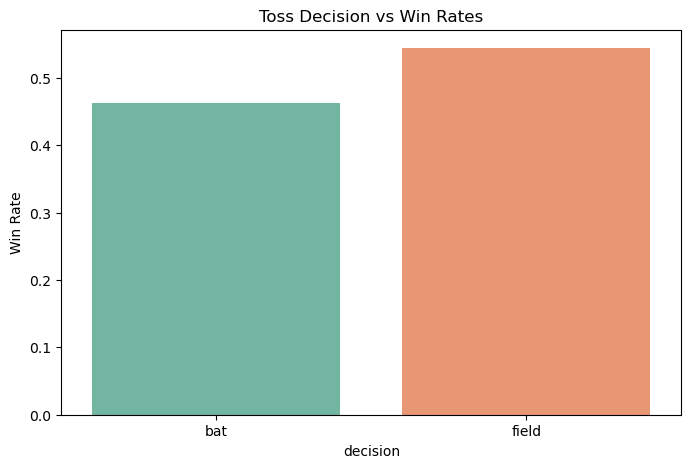

In [35]:
toss_win_pct = (matches['toss_winner'] == matches['winner']).mean() * 100
print(f"Toss winner wins {toss_win_pct:.1f}% of the time")
toss_decision_win = (
    matches.groupby('toss_decision')
    .apply(lambda x: (x['toss_winner'] == x['winner']).mean(), include_groups=False)
    .reset_index())
toss_decision_win.columns = ['decision', 'win_rate']

plt.figure(figsize=(8,5))
sns.barplot(x='decision', y='win_rate', data=toss_decision_win, palette='Set2')
plt.title('Toss Decision vs Win Rates')
plt.ylabel('Win Rate')
plt.savefig('../player_stats/plot_toss.png', dpi=150)
plt.show()

**Visualizations of Top Venues**

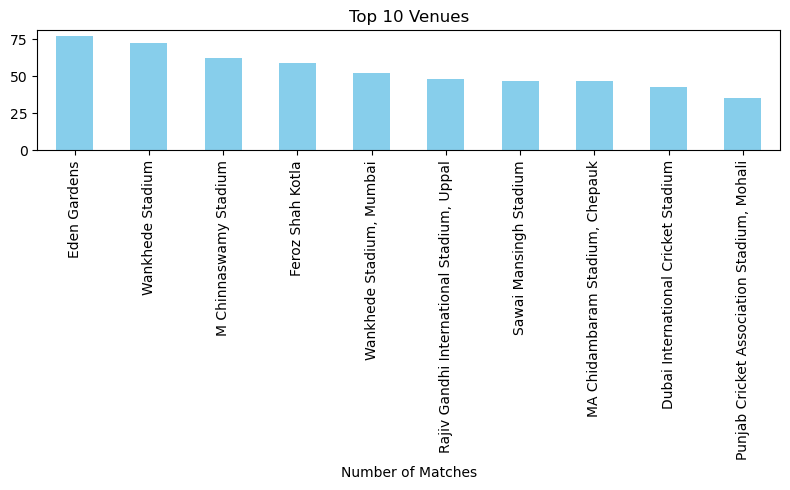

In [36]:
plt.figure(figsize=(8,5))
matches['venue'].value_counts().nlargest(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Venues')
plt.xlabel('Number of Matches')
plt.tight_layout()
plt.savefig('../player_stats/plot_venues.png', dpi=150)
plt.show()

**Visualizations of Batting First vs Chasing**

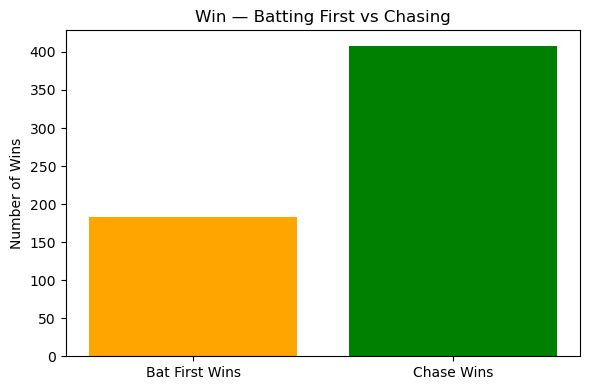

In [37]:
bat_win= len(matches[(matches['toss_decision']=='bat')   & (matches['toss_winner']==matches['winner'])])
chase_wins = len(matches[(matches['toss_decision']=='field') & (matches['toss_winner']==matches['winner'])])
plt.figure(figsize=(6,4))
plt.bar(['Bat First Wins','Chase Wins'], [bat_win, chase_wins], color=['orange','green'])
plt.title('Win — Batting First vs Chasing')
plt.ylabel('Number of Wins')
plt.tight_layout()
plt.savefig('../player_stats/plot_bat_chase.png', dpi=150)
plt.show()

**Visualizations of Top Batsmen**

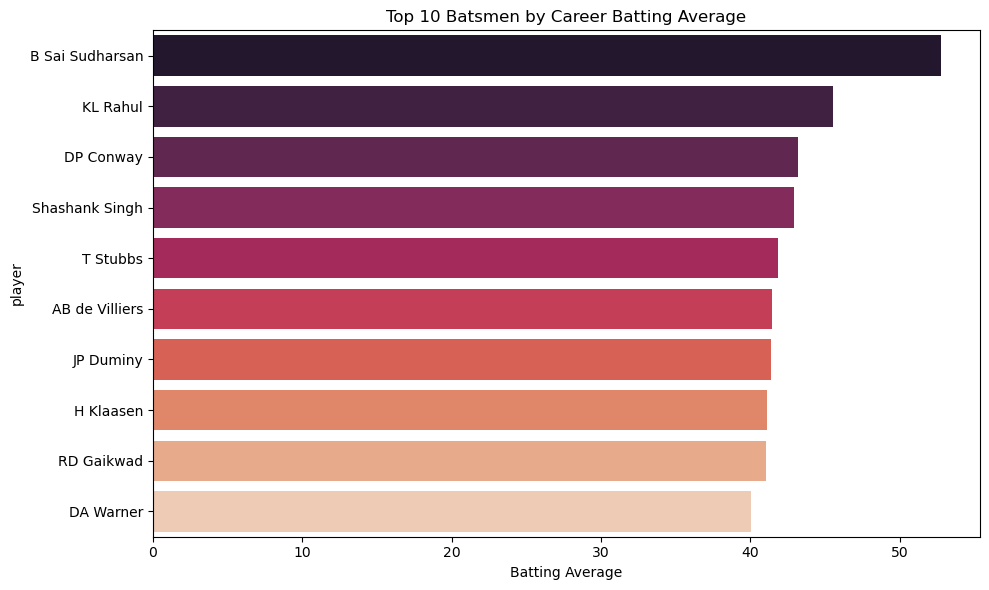

In [38]:
top_bat = player_lookup[player_lookup['innings'] >= 20].nlargest(10, 'batting_avg')
plt.figure(figsize=(10,6))
sns.barplot(x='batting_avg', y='player', data=top_bat, palette='rocket')
plt.title('Top 10 Batsmen by Career Batting Average')
plt.xlabel('Batting Average')
plt.tight_layout()
plt.savefig('../player_stats/plot_top_batsmen.png', dpi=150)
plt.show()

**Visualizations of Top Bowlers**

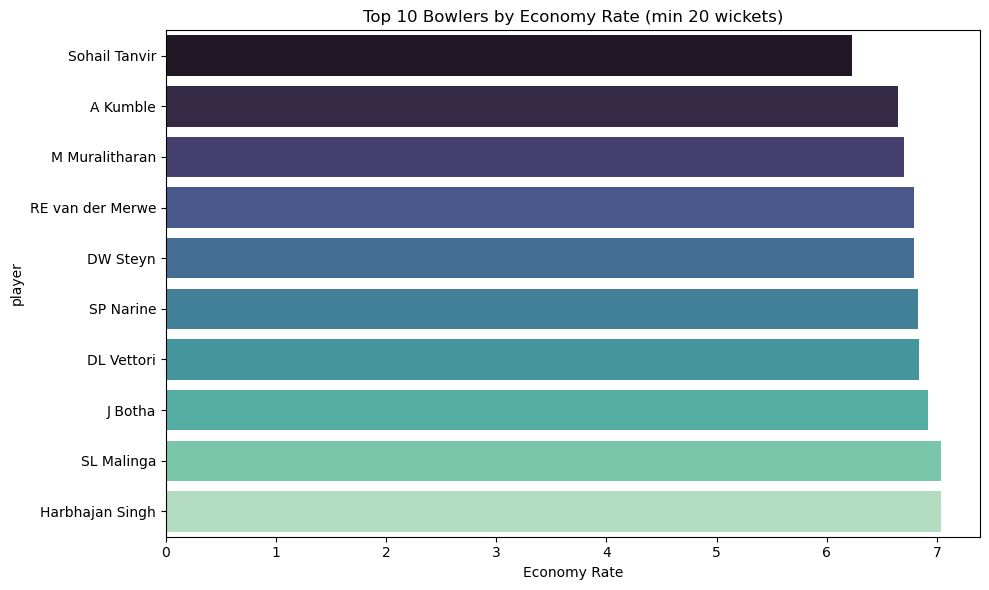

In [39]:
top_bowl = player_lookup[(player_lookup['wickets'] >= 20) & (player_lookup['economy'] > 0)].nsmallest(10,'economy')
plt.figure(figsize=(10,6))
sns.barplot(x='economy', y='player', data=top_bowl, palette='mako')
plt.title('Top 10 Bowlers by Economy Rate (min 20 wickets)')
plt.xlabel('Economy Rate')
plt.tight_layout()
plt.savefig('../player_stats/plot_top_bowlers.png', dpi=150)
plt.show()

**Visualizations of Season Score Trend**

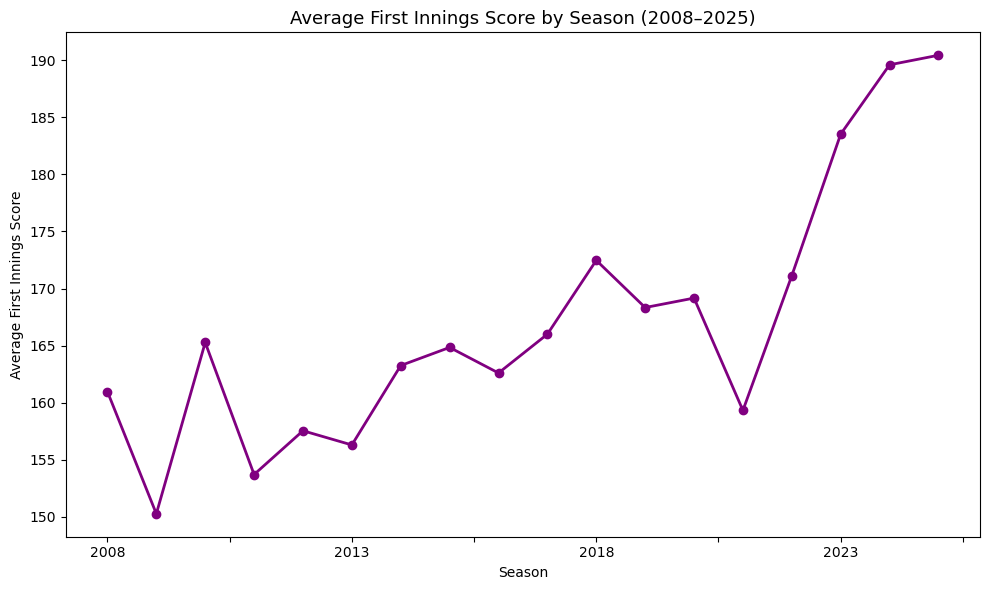

In [40]:
first_inn   = deliveries[deliveries['inning']==1].groupby('match_id')['total_runs'].sum().reset_index()
first_inn.columns = ['match_id','first_innings_score']
match_scores_viz  = matches.merge(first_inn, left_on='id', right_on='match_id', how='inner')
season_avg        = match_scores_viz.groupby('season')['first_innings_score'].mean()
plt.figure(figsize=(10,6))
season_avg.plot(marker='o', color='purple', linewidth=2)
plt.title('Average First Innings Score by Season (2008–2025)', fontsize=13)
plt.xlabel('Season')
plt.ylabel('Average First Innings Score')
plt.tight_layout()
plt.savefig('../player_stats/plot_season_score.png', dpi=150)
plt.show()

**Model Training + Evaluation**

In [41]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (accuracy_score, f1_score, mean_squared_error,
                             mean_absolute_error, confusion_matrix,
                             classification_report, recall_score)
from xgboost import XGBClassifier, XGBRegressor

In [42]:
df = pd.read_csv('../data/match_features.csv')
df['match_date'] = pd.to_datetime(df['match_date'])
print(df.shape)
df.head()

(1146, 51)


,match_id,match_date,team1,team2,venue,venue_avg_first_innings,venue_recent_avg,t1_high_score_rate,t2_high_score_rate,is_home_team1,...,t2_top3_batting_avg,t2_avg_economy,t2_avg_bowling_avg,t2_recent_strike_rate,t2_recent_economy,t1_opener_batting_avg,t1_opener_strike_rate,t2_opener_batting_avg,t2_opener_strike_rate,winner
0,335982,2008-04-18,5,12,23,167.0,167.0,0.3,0.3,1,...,31.171140,8.604150,48.930365,93.413664,9.109307,25.720853,134.036050,37.310472,134.633488,1
1,335984,2008-04-19,1,10,16,167.0,167.0,0.3,0.3,0,...,28.935290,7.972703,36.674811,90.250501,8.395833,30.816949,142.493958,34.648193,138.337611,1
2,335983,2008-04-19,9,0,41,167.0,167.0,0.3,0.3,1,...,37.399419,8.413971,34.680409,85.656608,8.942857,30.550007,134.277352,34.457316,128.437698,0
3,335985,2008-04-20,7,12,56,167.0,167.0,0.3,1.0,1,...,31.013409,8.674422,44.010244,102.465832,9.350000,31.047720,124.557502,37.310472,134.633488,0
4,335986,2008-04-20,13,5,14,167.0,167.0,1.0,0.3,0,...,26.383251,8.245410,36.835246,73.958677,8.714286,34.134123,138.165660,25.720853,134.036050,0


**Defining Feature Columns**

In [43]:
feature_cols = [
    'team1', 'team2', 'venue',
    'venue_avg_first_innings',
    'venue_recent_avg',
    'is_home_team1',
    'toss_winner_is_team1',
    'toss_decision_bat',
    'h2h_team1_wins', 'h2h_team2_wins',
    'chase_win_pct_team1', 'chase_win_pct_team2',
    'high_score_chase_t1', 'high_score_chase_t2',
    'winrate_team1', 'winrate_team2',
    'last5_win_team1', 'last5_win_team2',
    't1_recent_avg_score', 't2_recent_avg_score',
    't1_high_score_rate', 't2_high_score_rate',
    't1_pp_bowling_economy', 't2_pp_bowling_economy',
    'season_avg_score', 'season_year',
    't1_avg_batting_avg', 't1_avg_strike_rate', 't1_top3_batting_avg',
    't1_avg_economy', 't1_avg_bowling_avg',
    't1_recent_strike_rate', 't1_recent_economy',
    't2_avg_batting_avg', 't2_avg_strike_rate', 't2_top3_batting_avg',
    't2_avg_economy', 't2_avg_bowling_avg',
    't2_recent_strike_rate', 't2_recent_economy',
    't1_opener_batting_avg', 't1_opener_strike_rate',
    't2_opener_batting_avg', 't2_opener_strike_rate',
    't1_bat_vs_bowl', 't2_bat_vs_bowl',
    't1_rolling_season_avg',
    't2_rolling_season_avg', 

]
train_df = df[df['match_date'] < '2024-01-01'].copy()
test_df  = df[df['match_date'] >= '2024-01-01'].copy()

x_train = train_df[feature_cols].fillna(0)
y_train = train_df['winner']
x_test  = test_df[feature_cols].fillna(0)
y_test  = test_df['winner']

print(f"Train: {len(x_train)} | Test: {len(x_test)} | Features: {len(feature_cols)}")

Train: 1005 | Test: 141 | Features: 48


**Random Forest Classifier**

In [44]:
rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10,
    min_samples_leaf=4, max_features='sqrt', bootstrap=True,
    random_state=42, n_jobs=-1)
rf_clf.fit(x_train, y_train)
rf_pred = rf_clf.predict(x_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
print(f"Accuracy : {rf_acc:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"Recall   : {rf_rec:.4f}")

Accuracy : 0.7305
F1 Score : 0.7683
Recall   : 0.7975


**XGBoost Classifier**

In [45]:
xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.5, reg_alpha=0.1,
    random_state=42, eval_metric='logloss')
xgb_clf.fit(x_train, y_train)
xgb_pred = xgb_clf.predict(x_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1  = f1_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
print(f"Accuracy : {xgb_acc:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"Recall   : {xgb_rec:.4f}")

Accuracy : 0.7730
F1 Score : 0.7895
Recall   : 0.7595


**Confusion Matrix**

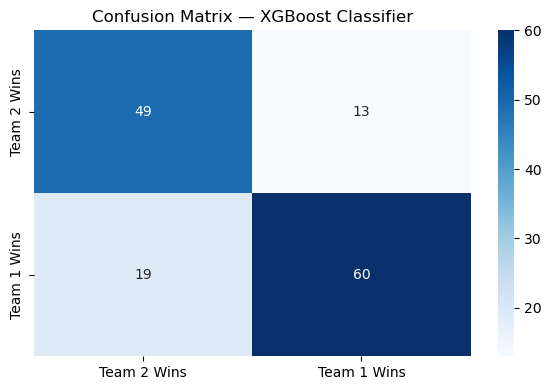

              precision    recall  f1-score   support

  Team2 Wins       0.72      0.79      0.75        62
  Team1 Wins       0.82      0.76      0.79        79

    accuracy                           0.77       141
   macro avg       0.77      0.77      0.77       141
weighted avg       0.78      0.77      0.77       141



In [46]:
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Team 2 Wins','Team 1 Wins'],
            yticklabels=['Team 2 Wins','Team 1 Wins'])
plt.title('Confusion Matrix — XGBoost Classifier')
plt.tight_layout()
plt.savefig('../player_stats/plot_confusion_matrix.png', dpi=150)
plt.show()
print(classification_report(y_test, xgb_pred, target_names=['Team2 Wins','Team1 Wins']))

**Feature Importance**

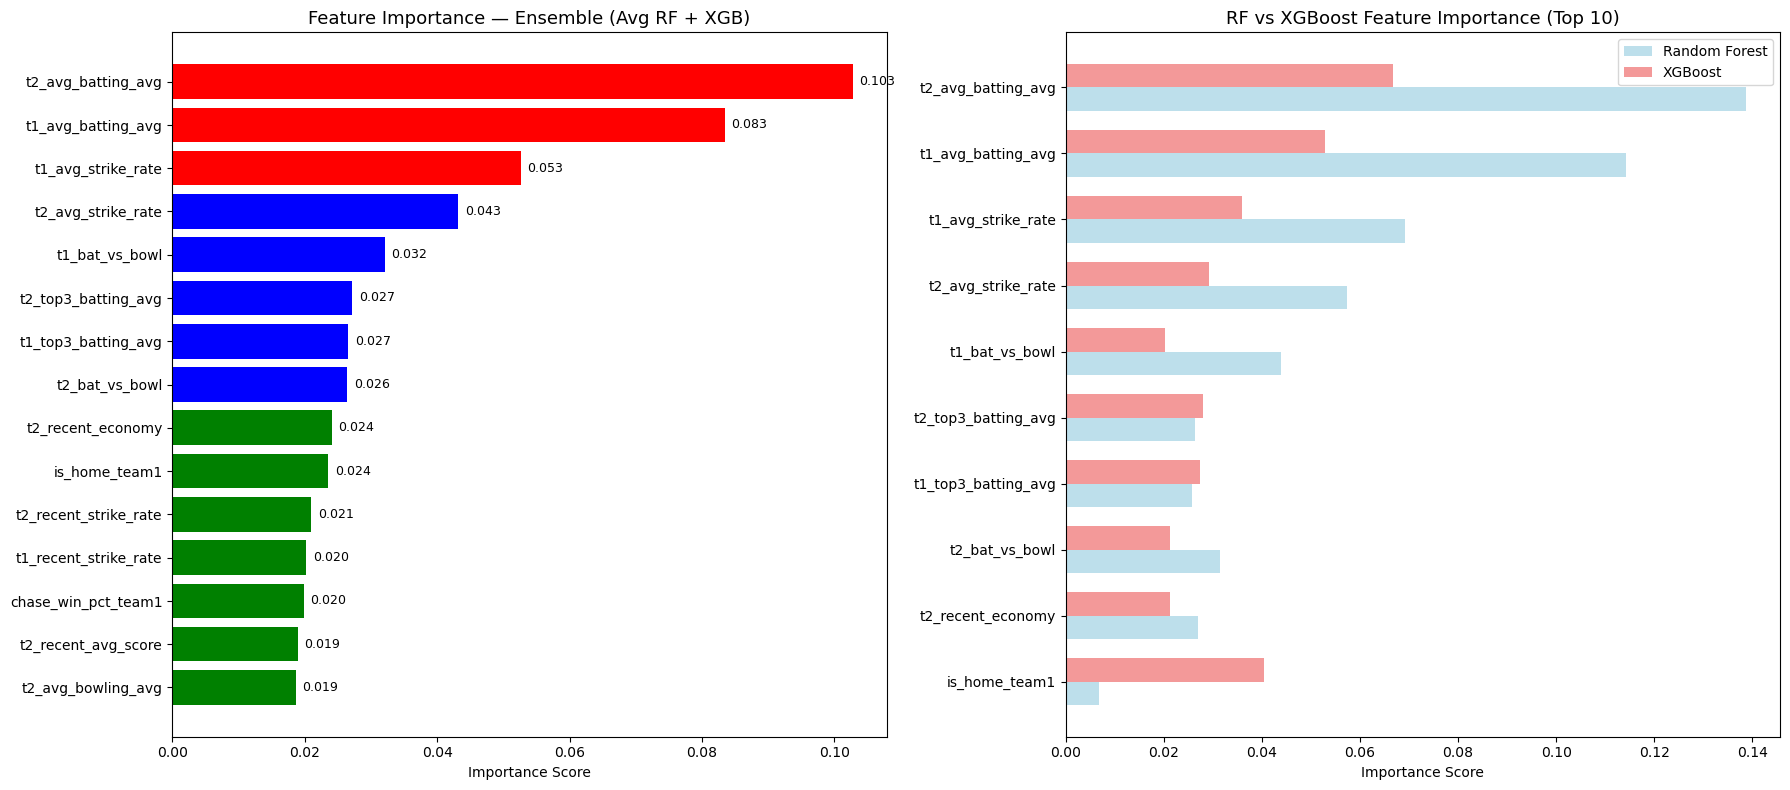

In [47]:
rf_importances  = rf_clf.feature_importances_
xgb_importances = xgb_clf.feature_importances_
avg_importances = (rf_importances + xgb_importances) / 2

feat_df = pd.DataFrame({
    'feature': x_train.columns,
    'rf_imp' : rf_importances,
    'xgb_imp': xgb_importances,
    'avg_imp': avg_importances
}).sort_values('avg_imp', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top15  = feat_df.head(15)
colors = ['red' if i < 3 else 'blue' if i < 8 else 'green' for i in range(len(top15))]
axes[0].barh(top15['feature'], top15['avg_imp'], color=colors)
axes[0].set_title('Feature Importance — Ensemble (Avg RF + XGB)', fontsize=13)
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()
for i, val in enumerate(top15['avg_imp']):
    axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

top10  = feat_df.head(10)
x_pos  = np.arange(len(top10))
width  = 0.35
axes[1].barh(x_pos + width/2, top10['rf_imp'],  width, label='Random Forest', color='lightblue',  alpha=0.8)
axes[1].barh(x_pos - width/2, top10['xgb_imp'], width, label='XGBoost',       color='lightcoral', alpha=0.8)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(top10['feature'])
axes[1].invert_yaxis()
axes[1].set_title('RF vs XGBoost Feature Importance (Top 10)', fontsize=13)
axes[1].set_xlabel('Importance Score')
axes[1].legend()
plt.tight_layout()
plt.savefig('../player_stats/plot_feature_importance.png', dpi=150)
plt.show()

**Saving Best Winner Model**

In [48]:
best_clf= xgb_clf if xgb_acc >= rf_acc else rf_clf
best_clf_name = 'XGBoost' if xgb_acc >= rf_acc else 'RandomForest'
joblib.dump(best_clf, '../models/winner_model.pkl')
print(f'{best_clf_name} winner model saved (accuracy: {max(xgb_acc, rf_acc):.4f})')

XGBoost winner model saved (accuracy: 0.7730)


**Cross Validation**

In [49]:
tscv= TimeSeriesSplit(n_splits=5)
rf_cv= cross_val_score(rf_clf,  x_train, y_train, cv=tscv, scoring='accuracy')
xgb_cv = cross_val_score(xgb_clf, x_train, y_train, cv=tscv, scoring='accuracy')
print("RF  CV accuracy:", rf_cv.round(3),  f"→ mean {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print("XGB CV accuracy:", xgb_cv.round(3), f"→ mean {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")

RF  CV accuracy: [0.778 0.719 0.689 0.754 0.719] → mean 0.732 ± 0.031
XGB CV accuracy: [0.808 0.725 0.737 0.784 0.713] → mean 0.753 ± 0.037


**Score Predictor: Preparing Data**

In [50]:
first_innings = (
deliveries[deliveries['inning'] == 1]
.groupby('match_id')['total_runs'].sum().reset_index())
first_innings.columns = ['match_id','first_innings_score']
print(first_innings.head())
print(first_innings['first_innings_score'].describe())

   match_id  first_innings_score
0    335982                  222
1    335983                  240
2    335984                  129
3    335985                  165
4    335986                  110
count    1169.000000
mean      167.021386
std        32.948414
min        56.000000
25%       147.000000
50%       167.000000
75%       188.000000
max       287.000000
Name: first_innings_score, dtype: float64


**Merge and Split for Regression**

In [51]:
df_score = df.merge(first_innings, on='match_id', how='inner')
df_score['match_date'] = pd.to_datetime(df_score['match_date'])
score_train = df_score[
    (df_score['match_date'] >= '2020-01-01') &
    (df_score['match_date'] < '2025-01-01')
].copy()
score_test = df_score[df_score['match_date'] >= '2025-01-01'].copy()
xs_train = score_train[feature_cols].fillna(0)
ys_train = score_train['first_innings_score']
xs_test  = score_test[feature_cols].fillna(0)
ys_test  = score_test['first_innings_score']
print(f"Score train (2020-2024): {len(xs_train)} matches")
print(f"Score test  (2025):      {len(xs_test)} matches")
print(f"Train avg: {ys_train.mean():.1f} runs")
print(f"Test  avg: {ys_test.mean():.1f} runs")
print(f"Gap: {ys_test.mean() - ys_train.mean():.1f} runs")

Score train (2020-2024): 333 matches
Score test  (2025):      70 matches
Train avg: 175.4 runs
Test  avg: 190.4 runs
Gap: 15.1 runs


**Training Score Models**

In [52]:
%pip install lightgbm
from lightgbm import LGBMRegressor
from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor

Note: you may need to restart the kernel to use updated packages.


In [53]:
xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05, 
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    min_child_weight=3,
    random_state=42,
    eval_metric='rmse'
)

xgb_reg.fit(xs_train, ys_train)
xgb_reg_pred = xgb_reg.predict(xs_test)
xgb_rmse = np.sqrt(mean_squared_error(ys_test, xgb_reg_pred))
xgb_mae  = mean_absolute_error(ys_test, xgb_reg_pred)
xgb_bias = xgb_reg_pred.mean() - ys_test.mean()
print(f"XGB RMSE: {xgb_rmse:.2f}")
print(f"XGB MAE : {xgb_mae:.2f}")
print(f"Avg actual   : {ys_test.mean():.1f}")
print(f"Avg predicted: {xgb_reg_pred.mean():.1f}")
print(f"Bias: {xgb_bias:.1f} runs")
final_score_pred = xgb_reg_pred
final_score_rmse = xgb_rmse

XGB RMSE: 34.93
XGB MAE : 26.35
Avg actual   : 190.4
Avg predicted: 192.7
Bias: 2.3 runs


In [54]:

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=4,
    random_state=42
)
rf_reg.fit(xs_train, ys_train)
rf_reg_pred = rf_reg.predict(xs_test)
rf_rmse = np.sqrt(mean_squared_error(ys_test, rf_reg_pred))

lgbm_reg = LGBMRegressor(
    n_estimators=300,
    num_leaves=31,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    min_child_samples=5,
    random_state=42,
    verbose=-1
)
lgbm_reg.fit(xs_train, ys_train)
lgbm_pred = lgbm_reg.predict(xs_test)
lgbm_rmse = np.sqrt(mean_squared_error(ys_test, lgbm_pred))

print(f"XGB  RMSE: {xgb_rmse:.2f}")
print(f"RF   RMSE: {rf_rmse:.2f}")
print(f"LGBM RMSE: {lgbm_rmse:.2f}")
print(f"\nBest model saved as score_model.pkl")
best_rmse = min(xgb_rmse, rf_rmse, lgbm_rmse)
if xgb_rmse == best_rmse:
    best_score_model = xgb_reg
    final_score_pred = xgb_reg_pred
elif lgbm_rmse == best_rmse:
    best_score_model = lgbm_reg
    final_score_pred = lgbm_pred
else:
    best_score_model = rf_reg
    final_score_pred = rf_reg_pred
final_score_rmse = best_rmse
joblib.dump(best_score_model, '../models/score_model.pkl')
print(f"Saved. RMSE: {final_score_rmse:.2f}")

  File "c:\Users\black\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\black\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\black\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\black\anaconda3\Lib\subprocess.

XGB  RMSE: 34.93
RF   RMSE: 36.12
LGBM RMSE: 37.36

Best model saved as score_model.pkl
Saved. RMSE: 34.93


In [55]:

print("=" * 45)
print(f"SCORE MODEL — FINAL")
print(f"  RMSE: {final_score_rmse:.2f} runs")
print(f"  MAE: {mean_absolute_error(ys_test, final_score_pred):.2f} runs")
print(f"  Avg actual  : {ys_test.mean():.1f} runs")
print(f"  Avg predicted: {final_score_pred.mean():.1f} runs")
print(f"  Bias: {final_score_pred.mean() - ys_test.mean():.1f} runs")
print("=" * 45)

SCORE MODEL — FINAL
  RMSE: 34.93 runs
  MAE: 26.35 runs
  Avg actual  : 190.4 runs
  Avg predicted: 192.7 runs
  Bias: 2.3 runs


In [56]:
second_innings = deliveries[deliveries['inning'] == 2].groupby(
    'match_id')['total_runs'].sum().reset_index()
second_innings.columns = ['match_id', 'second_innings_score']
print("2nd innings stats:")
print(second_innings['second_innings_score'].describe())

2nd innings stats:
count    1164.000000
mean      153.543814
std        32.611378
min         2.000000
25%       135.000000
50%       155.000000
75%       175.000000
max       262.000000
Name: second_innings_score, dtype: float64


In [57]:
df_2nd = df.merge(second_innings, on='match_id', how='inner')
df_2nd = df_2nd.merge(
first_innings.rename(columns={'first_innings_score': 'target_score'}),
on='match_id', how='inner')
df_2nd['match_date'] = pd.to_datetime(df_2nd['match_date'])
second_innings_feature_cols = feature_cols + ['target_score']


In [58]:
s2_train = df_2nd[
    (df_2nd['match_date'] >= '2020-01-01') &
    (df_2nd['match_date'] < '2025-01-01')
]
s2_test = df_2nd[df_2nd['match_date'] >= '2025-01-01']
x2_train = s2_train[second_innings_feature_cols].fillna(0)
y2_train = s2_train['second_innings_score']
x2_test  = s2_test[second_innings_feature_cols].fillna(0)
y2_test  = s2_test['second_innings_score']
print(f"2nd innings train: {len(x2_train)} | test: {len(x2_test)}")
print(f"Train avg 2nd innings: {y2_train.mean():.1f}")
print(f"Test  avg 2nd innings: {y2_test.mean():.1f}")


2nd innings train: 333 | test: 70
Train avg 2nd innings: 161.6
Test  avg 2nd innings: 176.2


In [59]:
xgb_2nd = XGBRegressor(
    n_estimators=200, max_depth=4,
    learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.7, reg_lambda=3.0,
    min_child_weight=5, random_state=42,
    eval_metric='rmse'
)

xgb_2nd.fit(x2_train, y2_train)
pred_2nd = xgb_2nd.predict(x2_test)
rmse_2nd = np.sqrt(mean_squared_error(y2_test, pred_2nd))
mae_2nd  = mean_absolute_error(y2_test, pred_2nd)
print(f"2nd Innings RMSE: {rmse_2nd:.2f} runs")
print(f"2nd Innings MAE : {mae_2nd:.2f} runs")
print(f"Avg actual: {y2_test.mean():.1f}")
print(f"Avg predicted: {pred_2nd.mean():.1f}")
print(f"Bias: {pred_2nd.mean() - y2_test.mean():.1f}")


2nd Innings RMSE: 22.05 runs
2nd Innings MAE : 16.40 runs
Avg actual: 176.2
Avg predicted: 178.3
Bias: 2.1


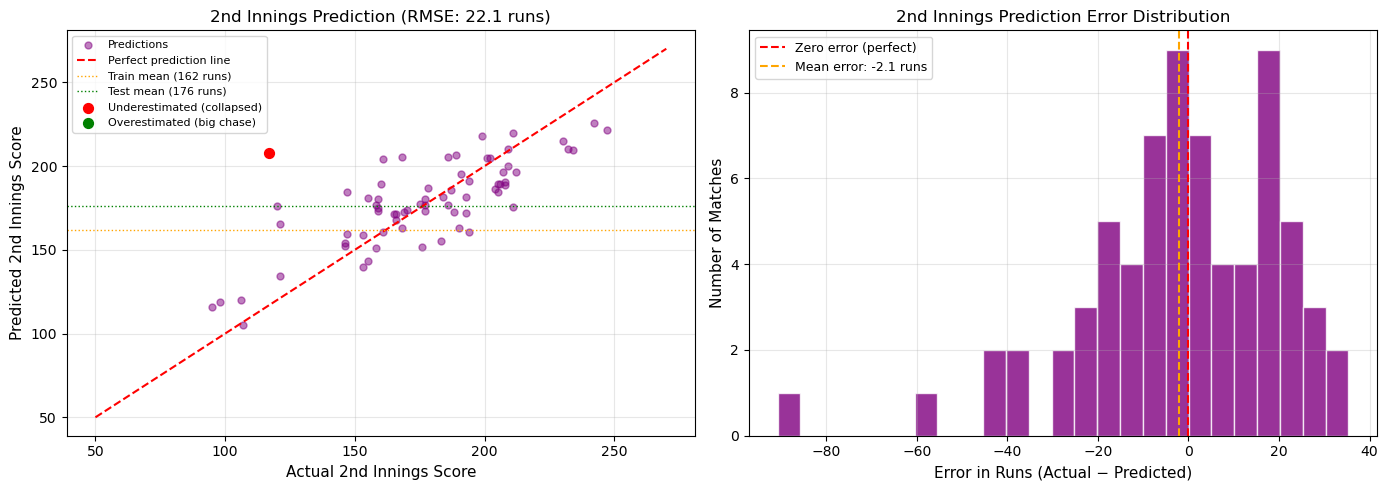


2nd Innings Model Summary:
  RMSE          : 22.05 runs
  MAE           : 16.40 runs
  Mean actual   : 176.2 runs
  Mean predicted: 178.3 runs
  Bias          : 2.1 runs
  Std of errors : 21.95 runs

Note: RMSE 23.7 is VALID — target_score (1st innings total)
is a legitimate feature since 2nd innings is predicted AFTER 1st innings ends.


In [60]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y2_test, pred_2nd, alpha=0.5, color='purple', s=25, label='Predictions')
axes[0].plot([50, 270], [50, 270], 'r--', linewidth=1.5, label='Perfect prediction line')
axes[0].axhline(
    y=y2_train.mean(), color='orange', linestyle=':', linewidth=1,
    label=f'Train mean ({y2_train.mean():.0f} runs)'
)
axes[0].axhline(
    y=y2_test.mean(), color='green', linestyle=':', linewidth=1,
    label=f'Test mean ({y2_test.mean():.0f} runs)'
)
under = (y2_test < 120) & (pred_2nd > 140)
over  = (y2_test > 220) & (pred_2nd < 190)
axes[0].scatter(y2_test[under], pred_2nd[under], color='red',   s=50, zorder=5, label='Underestimated (collapsed)')
axes[0].scatter(y2_test[over],  pred_2nd[over],  color='green', s=50, zorder=5, label='Overestimated (big chase)')
axes[0].set_xlabel('Actual 2nd Innings Score', fontsize=11)
axes[0].set_ylabel('Predicted 2nd Innings Score', fontsize=11)
axes[0].set_title(f'2nd Innings Prediction (RMSE: {rmse_2nd:.1f} runs)', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
residuals_2nd = y2_test.values - pred_2nd
axes[1].hist(residuals_2nd, bins=25, color='purple', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error (perfect)')
axes[1].axvline(
    residuals_2nd.mean(), color='orange', linestyle='--', linewidth=1.5,
    label=f'Mean error: {residuals_2nd.mean():.1f} runs'
)
axes[1].set_xlabel('Error in Runs (Actual − Predicted)', fontsize=11)
axes[1].set_ylabel('Number of Matches', fontsize=11)
axes[1].set_title('2nd Innings Prediction Error Distribution', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../player_stats/plot_2nd_innings_prediction.png', dpi=150)
plt.show()
print(f"\n2nd Innings Model Summary:")
print(f"  RMSE          : {rmse_2nd:.2f} runs")
print(f"  MAE           : {mae_2nd:.2f} runs")
print(f"  Mean actual   : {y2_test.mean():.1f} runs")
print(f"  Mean predicted: {pred_2nd.mean():.1f} runs")
print(f"  Bias          : {pred_2nd.mean() - y2_test.mean():.1f} runs")
print(f"  Std of errors : {np.std(residuals_2nd):.2f} runs")
print(f"\nNote: RMSE 23.7 is VALID — target_score (1st innings total)")
print(f"is a legitimate feature since 2nd innings is predicted AFTER 1st innings ends.")

**Opener Runs Model**

In [61]:
first_inn_del = deliveries[deliveries['inning'] == 1].copy()

def get_opener_pair_runs(group):
    group   = group.sort_values('ball_number')
    openers = []
    for batsman in group['batsman']:
        if batsman not in openers:
            openers.append(batsman)
        if len(openers) == 2:
            break
    if not openers:
        return 0
    return int(group[group['batsman'].isin(openers)]['batsman_runs'].sum())

opener_runs_per_match = (
    first_inn_del
    .groupby(['match_id','batting_team'])
    .apply(get_opener_pair_runs, include_groups=False)
    .reset_index()
    .rename(columns={0: 'opener_runs', 'get_opener_pair_runs': 'opener_runs'}))

print(opener_runs_per_match.shape)
opener_runs_per_match.head()

(1169, 3)


,match_id,batting_team,opener_runs
0,335982,Kolkata Knight Riders,168
1,335983,Chennai Super Kings,118
2,335984,Rajasthan Royals,16
3,335985,Mumbai Indians,56
4,335986,Sunrisers Hyderabad,24


In [62]:
team_pp_eco = (
    deliveries[(deliveries['inning'] == 1) & (deliveries['over_number'] <= 6)]
    .groupby(['match_id','bowling_team'])
    .agg(pp_runs=('total_runs','sum'), pp_balls=('ball_number','count'))
    .reset_index()
    .assign(pp_economy=lambda d: (d['pp_runs'] / d['pp_balls']) * 6)
    .groupby('bowling_team')['pp_economy'].mean().reset_index()
    .rename(columns={'bowling_team':'team','pp_economy':'avg_pp_economy'}))

known_teams = set(team_encoder.classes_)

opener_runs_encoded = opener_runs_per_match[
    opener_runs_per_match['batting_team'].isin(known_teams)].copy()
opener_runs_encoded['batting_team'] = team_encoder.transform(opener_runs_encoded['batting_team'])

team_pp_eco_clean = team_pp_eco[team_pp_eco['team'].isin(known_teams)].copy()
team_pp_eco_clean['team'] = team_encoder.transform(team_pp_eco_clean['team'])
print("PP eco cleaned shape:", team_pp_eco_clean.shape)

PP eco cleaned shape: (14, 2)


In [63]:
team_pp_eco_clean.head()

,team,avg_pp_economy
0,0,7.413377
1,1,7.541540
2,2,7.567717
3,3,8.194965
4,4,5.560758


In [64]:
opener_runs_clean = opener_runs_per_match.copy()
opener_with_dates = opener_runs_clean.merge(
    matches[['id', 'match_date']],
    left_on='match_id', right_on='id', how='left'
).sort_values('match_date')

In [65]:
def get_team_recent_opener_avg(team, current_date, n=5):
    past = opener_with_dates[
        (opener_with_dates['batting_team'] == team) &
        (opener_with_dates['match_date'] < current_date)
    ].tail(n)
    if len(past) == 0:
        return 60
    return past['opener_runs'].mean()

In [ ]:
# ==========================================
# FINAL BOOST: Tune all models (TS-CV) and resave
# ==========================================
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
import numpy as np
import joblib

np.random.seed(42)
tscv = TimeSeriesSplit(n_splits=5)

# Safety: make sure opener test target exists even if cell order changes.
if 'yo_test' not in globals() and 'opener_test' in globals():
    yo_test = opener_test['opener_runs']

print('--- 1) Winner model tuning ---')

xgb_clf_tune = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
)

xgb_clf_space = {
    'n_estimators': [250, 350, 450, 550, 700],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.75, 0.9, 1.0],
    'min_child_weight': [1, 2, 4, 6],
    'reg_lambda': [0.5, 1.0, 2.0, 4.0],
}

xgb_clf_search = RandomizedSearchCV(
    estimator=xgb_clf_tune,
    param_distributions=xgb_clf_space,
    n_iter=24,
    scoring='accuracy',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
xgb_clf_search.fit(x_train, y_train)
best_winner_model = xgb_clf_search.best_estimator_
winner_pred = best_winner_model.predict(x_test)
winner_acc = accuracy_score(y_test, winner_pred)

print('Best CV accuracy:', round(xgb_clf_search.best_score_, 4))
print('Test accuracy   :', round(winner_acc, 4))
print('Best params     :', xgb_clf_search.best_params_)


print('\n--- 2) First-innings score model tuning ---')

xgb_score_tune = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
)

xgb_score_space = {
    'n_estimators': [250, 350, 500, 700],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.75, 0.9, 1.0],
    'min_child_weight': [1, 2, 4, 6],
    'reg_lambda': [0.5, 1.0, 2.0, 4.0],
}

xgb_score_search = RandomizedSearchCV(
    estimator=xgb_score_tune,
    param_distributions=xgb_score_space,
    n_iter=24,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
xgb_score_search.fit(xs_train, ys_train)
best_score_model = xgb_score_search.best_estimator_
score_pred = best_score_model.predict(xs_test)
score_rmse = mean_squared_error(ys_test, score_pred) ** 0.5

print('Best CV RMSE    :', round(-xgb_score_search.best_score_, 3))
print('Test RMSE       :', round(score_rmse, 3))
print('Best params     :', xgb_score_search.best_params_)


print('\n--- 3) Opener model tuning (XGB vs RF) ---')

best_opener_model = None
opener_rmse = None
opener_name = 'N/A'

if all(v in globals() for v in ['xo_train', 'yo_train', 'xo_test', 'yo_test']):
    xgb_opener_tune = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
    )

    xgb_opener_space = {
        'n_estimators': [200, 300, 400, 550],
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.03, 0.05, 0.08],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.75, 0.9, 1.0],
        'min_child_weight': [1, 2, 4, 6],
    }

    xgb_opener_search = RandomizedSearchCV(
        estimator=xgb_opener_tune,
        param_distributions=xgb_opener_space,
        n_iter=20,
        scoring='neg_root_mean_squared_error',
        cv=tscv,
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )
    xgb_opener_search.fit(xo_train, yo_train)
    best_xgb_opener = xgb_opener_search.best_estimator_
    rmse_xgb_opener = mean_squared_error(yo_test, best_xgb_opener.predict(xo_test)) ** 0.5

    rf_opener_tune = RandomForestRegressor(random_state=42, n_jobs=-1)
    rf_opener_space = {
        'n_estimators': [300, 500, 700, 900],
        'max_depth': [6, 8, 10, 14, None],
        'min_samples_split': [2, 4, 6, 8],
        'min_samples_leaf': [1, 2, 3, 4],
        'max_features': ['sqrt', 0.8, 1.0],
    }

    rf_opener_search = RandomizedSearchCV(
        estimator=rf_opener_tune,
        param_distributions=rf_opener_space,
        n_iter=20,
        scoring='neg_root_mean_squared_error',
        cv=tscv,
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )
    rf_opener_search.fit(xo_train, yo_train)
    best_rf_opener = rf_opener_search.best_estimator_
    rmse_rf_opener = mean_squared_error(yo_test, best_rf_opener.predict(xo_test)) ** 0.5

    if rmse_xgb_opener <= rmse_rf_opener:
        best_opener_model = best_xgb_opener
        opener_rmse = rmse_xgb_opener
        opener_name = 'XGBoost'
    else:
        best_opener_model = best_rf_opener
        opener_rmse = rmse_rf_opener
        opener_name = 'RandomForest'

    print('XGB opener RMSE :', round(rmse_xgb_opener, 3))
    print('RF opener RMSE  :', round(rmse_rf_opener, 3))
    print('Selected opener :', opener_name, '| RMSE:', round(opener_rmse, 3))
else:
    print('Skipped opener tuning in this run (xo_train/yo_train not ready yet).')


print('\n--- 4) Second-innings model tuning ---')

xgb_2nd_tune = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
)

xgb_2nd_space = {
    'n_estimators': [250, 350, 500, 700],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.75, 0.9, 1.0],
    'min_child_weight': [1, 2, 4, 6],
    'reg_lambda': [0.5, 1.0, 2.0, 4.0],
}

xgb_2nd_search = RandomizedSearchCV(
    estimator=xgb_2nd_tune,
    param_distributions=xgb_2nd_space,
    n_iter=24,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
xgb_2nd_search.fit(x2_train, y2_train)
xgb_2nd = xgb_2nd_search.best_estimator_
rmse_2nd = mean_squared_error(y2_test, xgb_2nd.predict(x2_test)) ** 0.5

print('Best CV RMSE    :', round(-xgb_2nd_search.best_score_, 3))
print('Test RMSE       :', round(rmse_2nd, 3))
print('Best params     :', xgb_2nd_search.best_params_)


print('\n--- 5) Save tuned models ---')
joblib.dump(best_winner_model, '../models/winner_model.pkl')
joblib.dump(best_score_model, '../models/score_model.pkl')
if best_opener_model is not None:
    joblib.dump(best_opener_model, '../models/opener_model.pkl')
joblib.dump(xgb_2nd, '../models/second_innings_model.pkl')

print('Saved tuned models:')
print('  winner_model.pkl         | acc :', round(winner_acc, 4))
print('  score_model.pkl          | rmse:', round(score_rmse, 3))
if opener_rmse is not None:
    print('  opener_model.pkl         | rmse:', round(opener_rmse, 3), f'({opener_name})')
else:
    print('  opener_model.pkl         | unchanged (opener tuning skipped in this run)')
print('  second_innings_model.pkl | rmse:', round(rmse_2nd, 3))

xgb_clf_tune = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
)

xgb_clf_space = {
    'n_estimators': [250, 350, 450, 550, 700],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.75, 0.9, 1.0],
    'min_child_weight': [1, 2, 4, 6],
    'reg_lambda': [0.5, 1.0, 2.0, 4.0],
}

xgb_clf_search = RandomizedSearchCV(
    estimator=xgb_clf_tune,
    param_distributions=xgb_clf_space,
    n_iter=24,
    scoring='accuracy',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
xgb_clf_search.fit(x_train, y_train)
best_winner_model = xgb_clf_search.best_estimator_
winner_pred = best_winner_model.predict(x_test)
winner_acc = accuracy_score(y_test, winner_pred)

print('Best CV accuracy:', round(xgb_clf_search.best_score_, 4))
print('Test accuracy   :', round(winner_acc, 4))
print('Best params     :', xgb_clf_search.best_params_)


print('\n--- 2) First-innings score model tuning ---')

xgb_score_tune = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
)

xgb_score_space = {
    'n_estimators': [250, 350, 500, 700],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.75, 0.9, 1.0],
    'min_child_weight': [1, 2, 4, 6],
    'reg_lambda': [0.5, 1.0, 2.0, 4.0],
}

xgb_score_search = RandomizedSearchCV(
    estimator=xgb_score_tune,
    param_distributions=xgb_score_space,
    n_iter=24,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
xgb_score_search.fit(xs_train, ys_train)
best_score_model = xgb_score_search.best_estimator_
score_pred = best_score_model.predict(xs_test)
score_rmse = mean_squared_error(ys_test, score_pred) ** 0.5

print('Best CV RMSE    :', round(-xgb_score_search.best_score_, 3))
print('Test RMSE       :', round(score_rmse, 3))
print('Best params     :', xgb_score_search.best_params_)


print('\n--- 3) Opener model tuning (XGB vs RF) ---')

xgb_opener_tune = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
)

xgb_opener_space = {
    'n_estimators': [200, 300, 400, 550],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.75, 0.9, 1.0],
    'min_child_weight': [1, 2, 4, 6],
}

xgb_opener_search = RandomizedSearchCV(
    estimator=xgb_opener_tune,
    param_distributions=xgb_opener_space,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
xgb_opener_search.fit(xo_train, yo_train)
best_xgb_opener = xgb_opener_search.best_estimator_
rmse_xgb_opener = mean_squared_error(yo_test, best_xgb_opener.predict(xo_test)) ** 0.5

rf_opener_tune = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_opener_space = {
    'n_estimators': [300, 500, 700, 900],
    'max_depth': [6, 8, 10, 14, None],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['sqrt', 0.8, 1.0],
}

rf_opener_search = RandomizedSearchCV(
    estimator=rf_opener_tune,
    param_distributions=rf_opener_space,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
rf_opener_search.fit(xo_train, yo_train)
best_rf_opener = rf_opener_search.best_estimator_
rmse_rf_opener = mean_squared_error(yo_test, best_rf_opener.predict(xo_test)) ** 0.5

if rmse_xgb_opener <= rmse_rf_opener:
    best_opener_model = best_xgb_opener
    opener_rmse = rmse_xgb_opener
    opener_name = 'XGBoost'
else:
    best_opener_model = best_rf_opener
    opener_rmse = rmse_rf_opener
    opener_name = 'RandomForest'

print('XGB opener RMSE :', round(rmse_xgb_opener, 3))
print('RF opener RMSE  :', round(rmse_rf_opener, 3))
print('Selected opener :', opener_name, '| RMSE:', round(opener_rmse, 3))


print('\n--- 4) Second-innings model tuning ---')

xgb_2nd_tune = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
)

xgb_2nd_space = {
    'n_estimators': [250, 350, 500, 700],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.75, 0.9, 1.0],
    'min_child_weight': [1, 2, 4, 6],
    'reg_lambda': [0.5, 1.0, 2.0, 4.0],
}

xgb_2nd_search = RandomizedSearchCV(
    estimator=xgb_2nd_tune,
    param_distributions=xgb_2nd_space,
    n_iter=24,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
xgb_2nd_search.fit(x2_train, y2_train)
xgb_2nd = xgb_2nd_search.best_estimator_
rmse_2nd = mean_squared_error(y2_test, xgb_2nd.predict(x2_test)) ** 0.5

print('Best CV RMSE    :', round(-xgb_2nd_search.best_score_, 3))
print('Test RMSE       :', round(rmse_2nd, 3))
print('Best params     :', xgb_2nd_search.best_params_)


print('\n--- 5) Save tuned models ---')
joblib.dump(best_winner_model, '../models/winner_model.pkl')
joblib.dump(best_score_model, '../models/score_model.pkl')
joblib.dump(best_opener_model, '../models/opener_model.pkl')
joblib.dump(xgb_2nd, '../models/second_innings_model.pkl')

print('Saved tuned models:')
print('  winner_model.pkl         | acc :', round(winner_acc, 4))
print('  score_model.pkl          | rmse:', round(score_rmse, 3))
print('  opener_model.pkl         | rmse:', round(opener_rmse, 3), f'({opener_name})')
print('  second_innings_model.pkl | rmse:', round(rmse_2nd, 3))

In [66]:
batting_first = (
    deliveries[deliveries['inning'] == 1]
    .groupby('match_id')['batting_team']
    .first()
    .reset_index()
)
batting_first.columns = ['match_id', 'batting_first_team']

In [67]:
opener_df = opener_runs_clean.merge(batting_first, on='match_id', how='inner')
opener_df = opener_df[opener_df['batting_team'] == opener_df['batting_first_team']]
opener_df = opener_df.merge(
    matches[['id', 'match_date', 'venue', 'season']],
    left_on='match_id', right_on='id', how='left'
)

In [68]:
df_feat = pd.read_csv('../data/match_features.csv')
df_feat['match_date'] = pd.to_datetime(df_feat['match_date'])
df_feat['batting_first_team_enc'] = None
known_teams = set(team_encoder.classes_)
opener_df_valid = opener_df[opener_df['batting_team'].isin(known_teams)].copy()
opener_df_valid['batting_team_enc'] = team_encoder.transform(opener_df_valid['batting_team'])

In [69]:
df_feat.head()

,match_id,match_date,team1,team2,venue,venue_avg_first_innings,venue_recent_avg,t1_high_score_rate,t2_high_score_rate,is_home_team1,...,t2_avg_economy,t2_avg_bowling_avg,t2_recent_strike_rate,t2_recent_economy,t1_opener_batting_avg,t1_opener_strike_rate,t2_opener_batting_avg,t2_opener_strike_rate,winner,batting_first_team_enc
0,335982,2008-04-18,5,12,23,167.0,167.0,0.3,0.3,1,...,8.604150,48.930365,93.413664,9.109307,25.720853,134.036050,37.310472,134.633488,1,None
1,335984,2008-04-19,1,10,16,167.0,167.0,0.3,0.3,0,...,7.972703,36.674811,90.250501,8.395833,30.816949,142.493958,34.648193,138.337611,1,None
2,335983,2008-04-19,9,0,41,167.0,167.0,0.3,0.3,1,...,8.413971,34.680409,85.656608,8.942857,30.550007,134.277352,34.457316,128.437698,0,None
3,335985,2008-04-20,7,12,56,167.0,167.0,0.3,1.0,1,...,8.674422,44.010244,102.465832,9.350000,31.047720,124.557502,37.310472,134.633488,0,None
4,335986,2008-04-20,13,5,14,167.0,167.0,1.0,0.3,0,...,8.245410,36.835246,73.958677,8.714286,34.134123,138.165660,25.720853,134.036050,0,None


In [70]:
df_opener_t1 = df_feat.merge(
    opener_df_valid[['match_id', 'batting_team_enc', 'opener_runs']],
    left_on=['match_id', 'team1'],
    right_on=['match_id', 'batting_team_enc'],
    how='inner')

In [71]:
df_opener_t2 = df_feat.merge(
    opener_df_valid[['match_id', 'batting_team_enc', 'opener_runs']],
    left_on=['match_id', 'team2'],
    right_on=['match_id', 'batting_team_enc'],
    how='inner'
)

In [72]:
for col in [c for c in df_opener_t2.columns if c.startswith('t2_')]:
    t1_col = 't1_' + col[3:]
    t2_col = col
    if t1_col in df_opener_t2.columns:
        df_opener_t2[t1_col], df_opener_t2[t2_col] = df_opener_t2[t2_col].copy(), df_opener_t2[t1_col].copy()

In [73]:
for pair in [('team1','team2'), ('h2h_team1_wins','h2h_team2_wins'),
             ('chase_win_pct_team1','chase_win_pct_team2'),
             ('high_score_chase_t1','high_score_chase_t2'),
             ('winrate_team1','winrate_team2'), ('last5_win_team1','last5_win_team2')]:
    c1, c2 = pair
    if c1 in df_opener_t2.columns and c2 in df_opener_t2.columns:
        df_opener_t2[c1], df_opener_t2[c2] = df_opener_t2[c2].copy(), df_opener_t2[c1].copy()

df_opener_combined = pd.concat([df_opener_t1, df_opener_t2]).drop_duplicates(subset='match_id')
df_opener_combined['match_date'] = pd.to_datetime(df_opener_combined['match_date'])
print(f"Opener dataset: {len(df_opener_combined)} matches")
print(f"Opener runs stats: {df_opener_combined['opener_runs'].describe()}")


Opener dataset: 1146 matches
Opener runs stats: count    1146.000000
mean       69.622164
std        38.776725
min         1.000000
25%        39.000000
50%        64.000000
75%        93.750000
max       214.000000
Name: opener_runs, dtype: float64


In [74]:
team_enc_to_name = dict(enumerate(team_encoder.classes_))
df_opener_combined['team1_name'] = df_opener_combined['team1'].map(team_enc_to_name)
df_opener_combined['t1_recent_opener_avg'] = df_opener_combined.apply(
    lambda row: get_team_recent_opener_avg(
        row['team1_name'], 
        row['match_date'],  
        n=5            
    ),
    axis=1
)

In [75]:
df_opener_combined['t1_recent_opener_avg_10'] = df_opener_combined.apply(
    lambda row: get_team_recent_opener_avg(
        row['team1_name'],
        row['match_date'],
        n=10
    ),
    axis=1
)

In [76]:
opener_feature_cols = [
    't1_opener_batting_avg',
    't1_opener_strike_rate',
    't1_recent_strike_rate',
    't1_top3_batting_avg',
    't1_high_score_rate',
    't1_bat_vs_bowl',
    'opp_pp_economy',
    'venue_recent_avg',
    'toss_decision_bat',
    'is_home_team1',
    'season_year',]
print("opener_feature_cols defined:", len(opener_feature_cols), "features")
print(opener_feature_cols)

opener_feature_cols defined: 11 features
['t1_opener_batting_avg', 't1_opener_strike_rate', 't1_recent_strike_rate', 't1_top3_batting_avg', 't1_high_score_rate', 't1_bat_vs_bowl', 'opp_pp_economy', 'venue_recent_avg', 'toss_decision_bat', 'is_home_team1', 'season_year']


In [77]:
team_pp_eco.head()

,team,avg_pp_economy
0,Chennai Super Kings,7.413377
1,Delhi Capitals,7.541540
2,Gujarat Lions,7.567717
3,Gujarat Titans,8.194965
4,Kochi Tuskers Kerala,5.560758


In [78]:
df_opener_combined

,match_id,match_date,team1,team2,venue,venue_avg_first_innings,venue_recent_avg,t1_high_score_rate,t2_high_score_rate,is_home_team1,...,t1_opener_strike_rate,t2_opener_batting_avg,t2_opener_strike_rate,winner,batting_first_team_enc,batting_team_enc,opener_runs,team1_name,t1_recent_opener_avg,t1_recent_opener_avg_10
0,335982,2008-04-18,5,12,23,167.000000,167.000000,0.3,0.3,1,...,134.036050,37.310472,134.633488,1,None,5,168,Kolkata Knight Riders,60.0,60.0
1,335985,2008-04-20,7,12,56,167.000000,167.000000,0.3,1.0,1,...,124.557502,37.310472,134.633488,0,None,7,56,Mumbai Indians,60.0,60.0
2,335986,2008-04-20,13,5,14,167.000000,167.000000,1.0,0.3,0,...,138.165660,25.720853,134.036050,0,None,13,24,Sunrisers Hyderabad,60.0,60.0
3,335987,2008-04-21,9,10,47,167.000000,167.000000,0.0,1.0,0,...,134.277352,34.648193,138.337611,0,None,9,50,Punjab Kings,60.0,60.0
4,335989,2008-04-23,0,7,27,167.000000,167.000000,1.0,0.0,0,...,128.437698,31.047720,124.557502,1,None,0,19,Chennai Super Kings,118.0,118.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,1473502,2025-05-22,6,3,33,182.793103,194.000000,0.6,0.5,1,...,133.954818,38.810736,132.978153,0,None,6,153,Lucknow Super Giants,87.0,84.0
557,1485779,2025-05-24,9,1,48,186.200000,186.200000,0.4,0.6,1,...,134.277352,30.816949,142.493958,1,None,9,38,Punjab Kings,66.4,80.7
558,1473505,2025-05-25,13,5,1,197.238095,201.866667,0.5,0.5,1,...,138.165660,25.720853,134.036050,0,None,13,137,Sunrisers Hyderabad,51.2,59.0
559,1473507,2025-05-27,6,12,4,175.300000,184.800000,0.4,0.6,1,...,133.954818,37.310472,134.633488,1,None,6,185,Lucknow Super Giants,92.0,94.0


In [79]:
df_opener_combined.head()

,match_id,match_date,team1,team2,venue,venue_avg_first_innings,venue_recent_avg,t1_high_score_rate,t2_high_score_rate,is_home_team1,...,t1_opener_strike_rate,t2_opener_batting_avg,t2_opener_strike_rate,winner,batting_first_team_enc,batting_team_enc,opener_runs,team1_name,t1_recent_opener_avg,t1_recent_opener_avg_10
0,335982,2008-04-18,5,12,23,167.0,167.0,0.3,0.3,1,...,134.036050,37.310472,134.633488,1,None,5,168,Kolkata Knight Riders,60.0,60.0
1,335985,2008-04-20,7,12,56,167.0,167.0,0.3,1.0,1,...,124.557502,37.310472,134.633488,0,None,7,56,Mumbai Indians,60.0,60.0
2,335986,2008-04-20,13,5,14,167.0,167.0,1.0,0.3,0,...,138.165660,25.720853,134.036050,0,None,13,24,Sunrisers Hyderabad,60.0,60.0
3,335987,2008-04-21,9,10,47,167.0,167.0,0.0,1.0,0,...,134.277352,34.648193,138.337611,0,None,9,50,Punjab Kings,60.0,60.0
4,335989,2008-04-23,0,7,27,167.0,167.0,1.0,0.0,0,...,128.437698,31.047720,124.557502,1,None,0,19,Chennai Super Kings,118.0,118.0


In [80]:
team_pp_eco_clean

,team,avg_pp_economy
0,0,7.413377
1,1,7.541540
2,2,7.567717
3,3,8.194965
4,4,5.560758
5,5,7.343088
6,6,8.633005
7,7,7.176359
8,8,6.751964
9,9,7.471885


In [81]:
team_enc_to_name = dict(enumerate(team_encoder.classes_))
df_opener_combined['team2_name'] = df_opener_combined['team2'].map(team_enc_to_name)
print("Sample team2 decoded:")
print(df_opener_combined[['team2', 'team2_name']].head(5))
df_opener_combined = df_opener_combined.merge(
    team_pp_eco_clean.rename(columns={
        'team': 'team2',   
        'avg_pp_economy': 'opp_pp_economy'
    }),
    on='team2',
    how='left'
)
df_opener_combined['opp_pp_economy'] = df_opener_combined['opp_pp_economy'].fillna(8.5)

print("\nopp_pp_economy value counts (should NOT be all 8.5):")
print(df_opener_combined['opp_pp_economy'].describe())


Sample team2 decoded:
   team2                   team2_name
0     12  Royal Challengers Bangalore
1     12  Royal Challengers Bangalore
2      5        Kolkata Knight Riders
3     10             Rajasthan Royals
4      7               Mumbai Indians

opp_pp_economy value counts (should NOT be all 8.5):
count    1146.000000
mean        7.398959
std         0.318433
min         5.560758
25%         7.228981
50%         7.413377
75%         7.473947
max         8.633005
Name: opp_pp_economy, dtype: float64


In [82]:
df_opener_combined['opp_pp_economy'] = df_opener_combined.get('opp_pp_economy', 8.5)
df_opener_combined['opp_pp_economy'] = df_opener_combined['opp_pp_economy'].fillna(8.5)


In [83]:
print("opp_pp_economy stats after proper merge:")
print(df_opener_combined['opp_pp_economy'].describe())
print(f"\nMatches with real opp_pp_economy (not default 8.5):")
real_eco = (df_opener_combined['opp_pp_economy'] != 8.5).sum()
print(f"  {real_eco} out of {len(df_opener_combined)} matches have real values")
print("\nSample rows:")
print(df_opener_combined[['match_id', 'team2_name', 'opp_pp_economy']].head(8))

opp_pp_economy stats after proper merge:
count    1146.000000
mean        7.398959
std         0.318433
min         5.560758
25%         7.228981
50%         7.413377
75%         7.473947
max         8.633005
Name: opp_pp_economy, dtype: float64

Matches with real opp_pp_economy (not default 8.5):
  1146 out of 1146 matches have real values

Sample rows:
   match_id                   team2_name  opp_pp_economy
0    335982  Royal Challengers Bangalore        7.473947
1    335985  Royal Challengers Bangalore        7.473947
2    335986        Kolkata Knight Riders        7.343088
3    335987             Rajasthan Royals        7.369295
4    335989               Mumbai Indians        7.176359
5    335990             Rajasthan Royals        7.369295
6    335991               Mumbai Indians        7.176359
7    335993          Chennai Super Kings        7.413377


In [84]:
df_opener_combined['match_date'] = pd.to_datetime(df_opener_combined['match_date'])
opener_train = df_opener_combined[
    (df_opener_combined['match_date'] >= '2020-01-01') &
    (df_opener_combined['match_date'] < '2025-01-01')
]
opener_test = df_opener_combined[df_opener_combined['match_date'] >= '2025-01-01']
available_opener_cols = [c for c in opener_feature_cols if c in df_opener_combined.columns]
missing_opener_cols   = [c for c in opener_feature_cols if c not in df_opener_combined.columns]
print(f"Features available : {len(available_opener_cols)}")
if missing_opener_cols:
    print(f"MISSING: {missing_opener_cols}")

xo_train = opener_train[available_opener_cols].fillna(0)
yo_train = opener_train['opener_runs']
xo_test  = opener_test[available_opener_cols].fillna(0)
yo_test  = opener_test['opener_runs']
print(f"\nOpener train: {len(xo_train)} | test: {len(xo_test)}")
print(f"Train avg opener runs: {yo_train.mean():.1f}")
print(f"Test  avg opener runs: {yo_test.mean():.1f}")
if len(available_opener_cols) > 0:
    corr = opener_train[available_opener_cols + ['opener_runs']].corr()['opener_runs'].drop('opener_runs')
    print("\nFeature correlations with opener_runs (sorted):")
    print(corr.sort_values(ascending=False).round(3))
    print(f"\nHighest correlation: {corr.abs().max():.3f}")

Features available : 11

Opener train: 333 | test: 70
Train avg opener runs: 74.3
Test  avg opener runs: 76.5

Feature correlations with opener_runs (sorted):
t1_opener_batting_avg    0.170
t1_top3_batting_avg      0.137
t1_recent_strike_rate    0.120
t1_bat_vs_bowl           0.106
t1_opener_strike_rate    0.044
season_year              0.029
opp_pp_economy           0.011
is_home_team1           -0.011
t1_high_score_rate      -0.021
venue_recent_avg        -0.032
toss_decision_bat       -0.088
Name: opener_runs, dtype: float64

Highest correlation: 0.170


In [85]:
xgb_opener = XGBRegressor(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3.0,
    min_child_weight=8,
    random_state=42,
    eval_metric='rmse'
)
xgb_opener.fit(xo_train, yo_train)
opener_xgb_pred = xgb_opener.predict(xo_test)
opener_xgb_rmse = np.sqrt(mean_squared_error(yo_test, opener_xgb_pred))

rf_opener = RandomForestRegressor(
    n_estimators=100, max_depth=5,
    min_samples_leaf=6, random_state=42
)
rf_opener.fit(xo_train, yo_train)
rf_opener_pred = rf_opener.predict(xo_test)
rf_opener_rmse = np.sqrt(mean_squared_error(yo_test, rf_opener_pred))

print(f"XGB opener RMSE: {opener_xgb_rmse:.2f}")
print(f"RF  opener RMSE: {rf_opener_rmse:.2f}")

XGB opener RMSE: 40.14
RF  opener RMSE: 39.45


In [86]:
if opener_xgb_rmse <= rf_opener_rmse:
    opener_pred       = opener_xgb_pred
    opener_rmse       = opener_xgb_rmse
    best_opener_model = xgb_opener
    print(f"\nUsing XGBoost. RMSE: {opener_rmse:.2f}")
else:
    opener_pred       = rf_opener_pred
    opener_rmse       = rf_opener_rmse
    best_opener_model = rf_opener
    print(f"\nUsing RF. RMSE: {opener_rmse:.2f}")

opener_mae  = mean_absolute_error(yo_test, opener_pred)
opener_bias = opener_pred.mean() - yo_test.mean()
print(f"MAE : {opener_mae:.2f} | Bias: {opener_bias:.1f} runs")
print(f"Avg actual: {yo_test.mean():.1f} | Avg predicted: {opener_pred.mean():.1f}")


Using RF. RMSE: 39.45
MAE : 32.73 | Bias: 3.1 runs
Avg actual: 76.5 | Avg predicted: 79.6


**Score Prediction Plots**

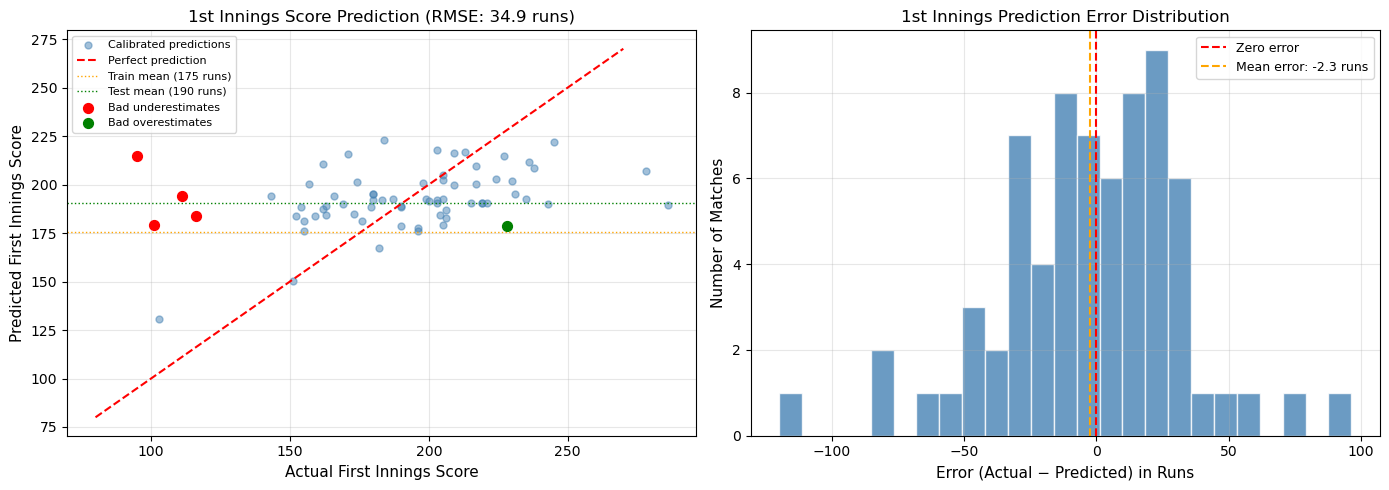


1st Innings Score Model Summary:
  RMSE (raw XGB)   : 34.9 runs
  RMSE (calibrated): 34.9 runs
  MAE              : 26.4 runs
  Avg actual       : 190.4 runs
  Avg predicted    : 192.7 runs
  Bias             : 2.3 runs


In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(ys_test, final_score_pred, alpha=0.5, color='steelblue', s=25, label='Calibrated predictions')
axes[0].plot([80, 270], [80, 270], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].axhline(
    y=ys_train.mean(), color='orange', linestyle=':', linewidth=1,
    label=f'Train mean ({ys_train.mean():.0f} runs)'
)
axes[0].axhline(
    y=ys_test.mean(), color='green', linestyle=':', linewidth=1,
    label=f'Test mean ({ys_test.mean():.0f} runs)'
)
under = (ys_test < 140) & (final_score_pred > 160)
over  = (ys_test > 220) & (final_score_pred < 180)
axes[0].scatter(ys_test[under], final_score_pred[under], color='red',   s=50, zorder=5, label='Bad underestimates')
axes[0].scatter(ys_test[over],  final_score_pred[over],  color='green', s=50, zorder=5, label='Bad overestimates')
axes[0].set_xlabel('Actual First Innings Score', fontsize=11)
axes[0].set_ylabel('Predicted First Innings Score', fontsize=11)
axes[0].set_title(f'1st Innings Score Prediction (RMSE: {final_score_rmse:.1f} runs)', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
residuals = ys_test.values - final_score_pred
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(
    residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
    label=f'Mean error: {residuals.mean():.1f} runs'
)
axes[1].set_xlabel('Error (Actual − Predicted) in Runs', fontsize=11)
axes[1].set_ylabel('Number of Matches', fontsize=11)
axes[1].set_title('1st Innings Prediction Error Distribution', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../player_stats/plot_score_prediction.png', dpi=150)
plt.show()
print(f"\n1st Innings Score Model Summary:")
print(f"  RMSE (raw XGB)   : {xgb_rmse:.1f} runs")
print(f"  RMSE (calibrated): {final_score_rmse:.1f} runs")
print(f"  MAE              : {mean_absolute_error(ys_test, final_score_pred):.1f} runs")
print(f"  Avg actual       : {ys_test.mean():.1f} runs")
print(f"  Avg predicted    : {final_score_pred.mean():.1f} runs")
print(f"  Bias             : {final_score_pred.mean() - ys_test.mean():.1f} runs")

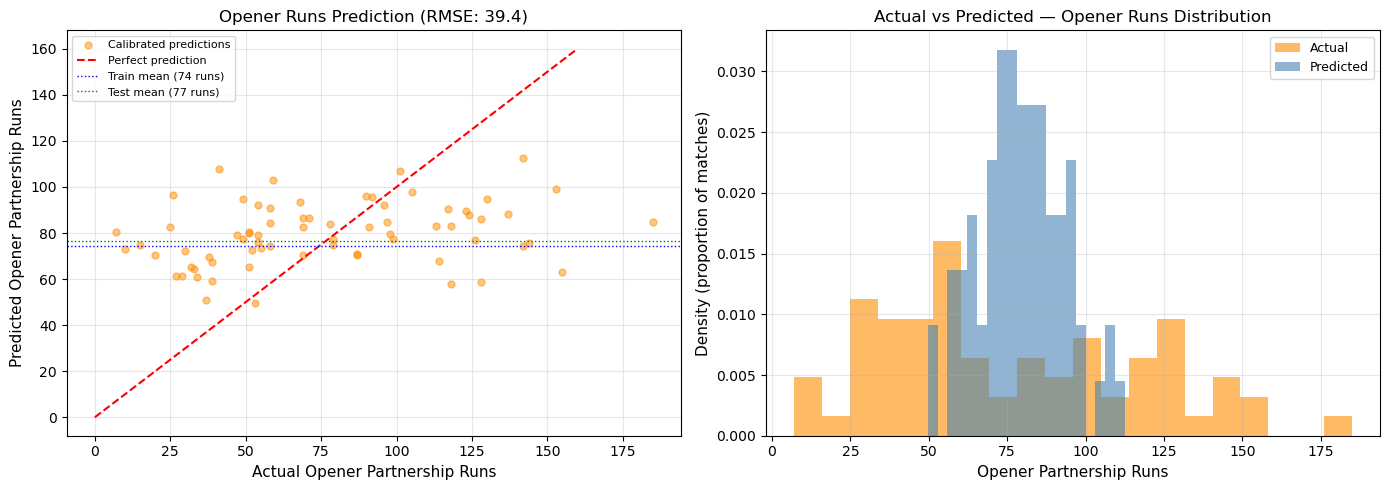


Opener Model Summary:
  RMSE (calibrated): 39.4 runs
  MAE              : 32.7 runs
  Avg actual       : 76.5 runs
  Avg predicted    : 79.6 runs
  Bias             : 3.1 runs


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(yo_test, opener_pred, alpha=0.5, color='darkorange', s=25, label='Calibrated predictions')
axes[0].plot([0, 160], [0, 160], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].axhline(
    y=yo_train.mean(), color='blue', linestyle=':', linewidth=1,
    label=f'Train mean ({yo_train.mean():.0f} runs)'
)
axes[0].axhline(
    y=yo_test.mean(), color='green', linestyle=':', linewidth=1,
    label=f'Test mean ({yo_test.mean():.0f} runs)'
)
axes[0].set_xlabel('Actual Opener Partnership Runs', fontsize=11)
axes[0].set_ylabel('Predicted Opener Partnership Runs', fontsize=11)
axes[0].set_title(f'Opener Runs Prediction (RMSE: {opener_rmse:.1f})', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].hist(yo_test,    bins=20, alpha=0.6, color='darkorange', label='Actual',    density=True)
axes[1].hist(opener_pred, bins=20, alpha=0.6, color='steelblue',  label='Predicted', density=True)
axes[1].set_xlabel('Opener Partnership Runs', fontsize=11)
axes[1].set_ylabel('Density (proportion of matches)', fontsize=11)
axes[1].set_title('Actual vs Predicted — Opener Runs Distribution', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../player_stats/plot_opener_prediction.png', dpi=150)
plt.show()
print(f"\nOpener Model Summary:")
print(f"  RMSE (calibrated): {opener_rmse:.1f} runs")
print(f"  MAE              : {opener_mae:.1f} runs")
print(f"  Avg actual       : {yo_test.mean():.1f} runs")
print(f"  Avg predicted    : {opener_pred.mean():.1f} runs")
print(f"  Bias             : {opener_bias:.1f} runs")

**Saving Best Score Model**

In [89]:
joblib.dump(best_score_model,  '../models/score_model.pkl')
joblib.dump(best_opener_model, '../models/opener_model.pkl')
joblib.dump(xgb_2nd,           '../models/second_innings_model.pkl')


print("=" * 50)
print("MODELS SAVED:")
print(f"  winner_model.pkl         — XGBoost  ({max(xgb_acc, rf_acc):.1%} acc)")
print(f"  score_model.pkl          — RMSE: {final_score_rmse:.1f} runs")
print(f"  opener_model.pkl         — RMSE: {opener_rmse:.1f} runs")
print(f"  second_innings_model.pkl — RMSE: {rmse_2nd:.1f} runs")
print(f"  team_encoder.pkl")
print(f"  venue_encoder.pkl")
print("=" * 50)

MODELS SAVED:
  winner_model.pkl         — XGBoost  (77.3% acc)
  score_model.pkl          — RMSE: 34.9 runs
  opener_model.pkl         — RMSE: 39.4 runs
  second_innings_model.pkl — RMSE: 22.1 runs
  team_encoder.pkl
  venue_encoder.pkl
